# Time evolution II — Chebyshev propagation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 5 — Ground states and unitary dynamics*

## 1. Introduction and motivation

**The question.** We want the solution of the time-dependent Schrödinger equation for a chain of $N$ interacting
spins ($\hbar = 1$ throughout),

$$ i\,\frac{d}{dt}|\psi(t)\rangle = H|\psi(t)\rangle \qquad\Longrightarrow\qquad |\psi(t)\rangle = e^{-iHt}\,|\psi(0)\rangle , $$

for a time-independent Hamiltonian $H$. In the [previous notebook](12_tebd_trotter_suzuki.ipynb) we *split* the exponential
into many small two-spin gates (TEBD / Trotter–Suzuki). That method is simple and robust, but it has a built-in
**Trotter error** that decreases only as a power of the time step, $\mathcal{O}(dt^{p})$: every additional digit of accuracy costs a
fixed *factor* more work. Three digits are cheap; ten digits, needed to compute an echo
$|\langle\psi(0)|\psi(t)\rangle|^2$ that is itself $10^{-6}$, to benchmark another code, to separate a genuinely small
physical effect from numerical error, or to evolve for a very long time, cost orders of magnitude more (§12, §13).

**The idea of this notebook.** The only thing our matrix-free simulator can do with $H$ is to *apply it to a state*,
$|\phi\rangle \mapsto H|\phi\rangle$ (notebook [Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb)).
With $K$ such applications we can build $p(H)|\psi\rangle$ for **any polynomial** $p$ of degree $K$. So the question becomes one of
*approximation theory*:

> Which polynomial $p_K(x)$ of degree $K$ is the best approximation of the function $f(x) = e^{-ixt}$ on the interval that contains the spectrum of $H$?

The answer — numerically stable, known in closed form, and within a factor that grows only like $\log K$ of the best
polynomial of degree $K$ that exists (Trefethen, *Approximation Theory and Approximation Practice*, Ch. 16) — is the **Chebyshev expansion**

$$ e^{-iHt} \;=\; e^{-ibt}\sum_{k=0}^{\infty} (2-\delta_{k0})\,(-i)^k\,J_k(at)\;T_k\!\Big(\frac{H-b}{a}\Big), $$

where $T_k$ are Chebyshev polynomials, $J_k$ are Bessel functions and $a,b$ rescale the spectrum of $H$ into $[-1,1]$.
Its error decays **faster than exponentially** once $K$ exceeds $at$: going from 4 to 13 digits costs 26 extra
applications of $H$ (103 → 129 in the example of §12). This propagator was introduced in quantum molecular dynamics by Tal-Ezer and Kosloff (1984), was recommended for time-independent
Hamiltonians in the comparison of propagation schemes by Leforestier *et al.* (1991), and is today a standard tool for exact dynamics of spin chains, quantum chaos and entanglement growth, time-dependent
spectral functions, and everywhere a *numerically exact* reference is needed for $N \sim 20$–$30$ spins (Fehske *et al.* 2009 benchmark it
against other time-evolution schemes).

**Road map.** We assume you have never met Chebyshev polynomials or Bessel functions.

1. Why polynomials, and why the obvious one (Taylor) fails (§2).
2. Chebyshev polynomials: definition, recurrence, properties (§3). Bessel functions as Fourier coefficients (§4).
3. The Jacobi–Anger identity, derived and verified numerically for *numbers* (§5); how many terms are needed (§6).
4. From numbers to *operators*: functions of a Hermitian matrix, spectral rescaling, dense validation, and the same recurrence for other functions of $H$ (§7);
   estimating the spectral bounds and what happens when they are wrong (§8).
5. The matrix-free `lax.scan` implementation (§9), validated to machine precision (§10).
6. Physics: a quench in a non-integrable spin chain, by chaining steps (§11).
7. Cost compared with TEBD at fixed accuracy (§12); long-time evolution and the choice of the step (§13); the reach in system size (§14).

### What you will learn

*Physics*

* how a closed many-body system evolves after a sudden quench, computed with no time-step error at all;
* why the *spectral width* of $H$, which grows linearly with $N$, sets the cost of exact dynamics.

*Numerical methods*

* Chebyshev polynomials and Chebyshev series (a Fourier cosine series in disguise); Bessel functions $J_k(z)$ and their decay for $k>z$;
* the Jacobi–Anger expansion and the number-of-terms rule $K \approx at + c\,(at)^{1/3}$;
* why a Taylor expansion of $e^{-iHt}$ is numerically useless and the Chebyshev one is not (catastrophic cancellation);
* spectral rescaling, Lanczos bounds, safety factors, and the exponential blow-up if the spectrum leaks out of $[-1,1]$;
* what is left when a method has no time-step error: truncation and round-off, how large each is, and how they accumulate over chained steps;
* work–precision diagrams: comparing algorithms at *equal accuracy*.

*Implementation practice*

* a three-term recurrence on $2^N$-component states as a `jax.lax.scan` with a three-vector carry;
* separating *set-up code* (NumPy/SciPy, run once: coefficients) from the *hot loop* (JAX, jit-compiled);
* using the outputs of `scan` to get a whole convergence curve from a single run;
* validating against dense linear algebra, conservation laws and time reversal.

### Prerequisites
* [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (`jit`, `lax.scan`),
  [Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) (`apply_gate`, `apply_hamiltonian`);
* [Time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb) (exact propagator by diagonalisation);
* [Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb) (Lanczos) and
  [TEBD](12_tebd_trotter_suzuki.ipynb) (Trotter–Suzuki splitting), which we use as the competitor.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## Engine recap

The cell below (folded on the website) contains the simulator primitives used in this notebook, exactly as derived in
Chapters 1–4 and in the first two notebooks of this chapter: `apply_gate` (one einsum per local operator), `heisenberg_terms`
(a Hamiltonian is a *list of local terms*), `apply_hamiltonian` (the matrix-free product $H|\psi\rangle$), `dense_hamiltonian` (dense reference for validation on small chains), `tebd_gates` (the competitor), `spectral_bounds` (a short
Lanczos run) and the production version of what we are about to derive, `chebyshev_evolve`.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def spectral_bounds(terms, N, m=40, key=None):
    """Cheap estimate of (E_min, E_max) from a short Lanczos run -- needed to rescale H into [-1,1]
    for the Chebyshev expansion."""
    key = jax.random.PRNGKey(1) if key is None else key
    a, b, _ = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), haar_state(key, N), m)
    w = np.linalg.eigvalsh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    return float(w[0]), float(w[-1])

def chebyshev_evolve(psi, terms, t, bounds, tol=1e-13, safety=1.02):
    """exp(-iHt)|psi> by Chebyshev expansion (Tal-Ezer & Kosloff) -- no Trotter error.

    MATH   rescale  Ht = (H - b)/a  with a = (Emax-Emin)/2, b = (Emax+Emin)/2   => spectrum in [-1,1]
           Jacobi-Anger:   e^{-i a t x} = sum_k (2 - delta_k0) (-i)^k J_k(a t) T_k(x)
           =>  e^{-iHt}|psi> = e^{-i b t} sum_k c_k |phi_k>,    c_k = (2-delta_k0)(-i)^k J_k(a t)
           recurrence     |phi_0> = |psi>, |phi_1> = Ht|psi>, |phi_{k+1}> = 2 Ht|phi_k> - |phi_{k-1}>.
    CONVERGENCE   J_k(at) decays super-exponentially for k > a t: the number of terms is ~ a t + O(10),
           and the error can be pushed to machine precision.  Memory: 3 vectors.
    JAX    the recurrence is a `lax.scan` whose carry is (phi_{k-1}, phi_k, accumulated sum).
    """
    from scipy.special import jv
    Emin, Emax = bounds
    a, b = safety * (Emax - Emin) / 2.0, (Emax + Emin) / 2.0
    K = int(np.ceil(a * abs(t))) + 20
    while abs(jv(K, a * t)) > tol:
        K += 10
    coef = jnp.asarray([(1 if k == 0 else 2) * ((-1j) ** k) * jv(k, a * t) for k in range(K + 1)], dtype=CDTYPE)

    def Ht(p):
        return (apply_hamiltonian(terms, p) - b * p) / a

    T0, T1 = psi, Ht(psi)
    acc0 = coef[0] * T0 + coef[1] * T1

    def body(carry, c):
        Tm, Tc, acc = carry
        Tn = 2 * Ht(Tc) - Tm
        return (Tc, Tn, acc + c * Tn), None

    (_, _, acc), _ = lax.scan(body, (T0, T1, acc0), coef[2:])
    return jnp.exp(-1j * b * t) * acc


## 2. Polynomial approximation and the failure of the Taylor series

### 2.1 The only thing we can afford is $H|\phi\rangle$

A state of $N$ spins is a tensor with $2^N$ complex amplitudes. The matrix of $H$ would have $4^N$ entries and
$e^{-iHt}$ (a full matrix even when $H$ is sparse) as well: at $N=20$ that is $10^{12}$ numbers, 16 TB. What we *can* do, at a
cost of $\mathcal{O}(N 2^N)$ operations and no extra memory, is to apply $H$ — a sum of $\sim 2N$ local terms — to a state.
Applying $H$ twice gives $H^2|\psi\rangle$, and so on, so that after $K$ applications we can assemble any

$$ p_K(H)|\psi\rangle = \sum_{k=0}^{K} \alpha_k H^k|\psi\rangle . $$

If $H = \sum_n E_n |n\rangle\langle n|$ is the eigen-decomposition, then $p_K(H) = \sum_n p_K(E_n)|n\rangle\langle n|$ (we will verify this in
§7), so the error of replacing $e^{-iHt}$ by $p_K(H)$ is

$$ \big\| e^{-iHt} - p_K(H) \big\| \;=\; \max_n \big| e^{-iE_nt} - p_K(E_n) \big| \;\le\; \max_{x\in[E_{\min},E_{\max}]} \big| e^{-ixt} - p_K(x) \big| . \qquad (1)$$

**The many-body problem has been reduced to a one-dimensional problem about ordinary functions**: approximate
$e^{-ixt}$ by a polynomial, uniformly on an interval. We do not need to know the eigenvalues — only an interval that contains them.

### 2.2 Catastrophic cancellation in the Taylor series

The Taylor series $e^{-ixt} = \sum_k (-ixt)^k/k!$ converges for every $x$, so why not truncate it? Let us try for a single
number. With $z = xt = 30$ (a modest value: for our chains $|E|_{\max}\approx 2N$, so this is $N=15$ at $t=1$):

largest term of the series : 7.762e+11   (at k = 29)
best error ever reached    : 5.861e-05
double-precision epsilon   : 2.220e-16


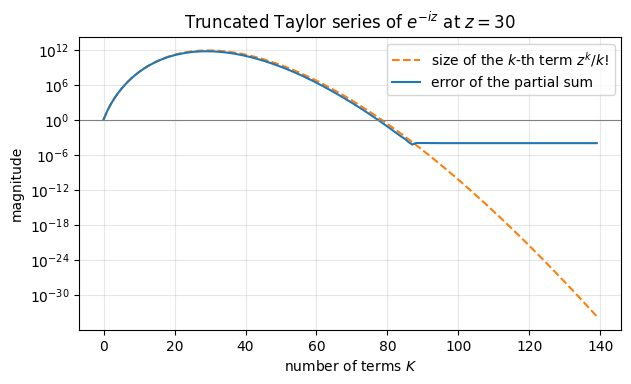

In [3]:
# ==============================================================================
# EXPERIMENT: truncated Taylor series of exp(-i z) for a single number z
# ==============================================================================
from math import factorial

z = 30.0
exact = np.exp(-1j * z)
partial, term, taylor_err, taylor_terms = 0.0 + 0.0j, 1.0 + 0.0j, [], []
for k in range(140):
    partial += term                       # add (-i z)^k / k!
    taylor_err.append(abs(partial - exact))
    taylor_terms.append(abs(term))
    term *= (-1j * z) / (k + 1)           # next term from the previous one (no overflow of z^k or k!)

print(f"largest term of the series : {max(taylor_terms):.3e}   (at k = {int(np.argmax(taylor_terms))})")
print(f"best error ever reached    : {min(taylor_err):.3e}")
print(f"double-precision epsilon   : {np.finfo(float).eps:.3e}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.semilogy(taylor_terms, "C1--", label=r"size of the $k$-th term $z^k/k!$")
ax.semilogy(taylor_err, "C0-", label=r"error of the partial sum")
ax.axhline(1.0, color="gray", lw=0.8)
ax.set_xlabel("number of terms $K$"); ax.set_ylabel("magnitude")
ax.set_title(r"Truncated Taylor series of $e^{-iz}$ at $z=30$")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

**Interpretation.** The terms $z^k/k!$ first *grow*, up to $\sim 10^{12}$ at $k\approx z$, before the factorial wins. The result,
however, has modulus 1: the sum must cancel twelve orders of magnitude. Floating-point numbers carry about 16 digits, so
after the cancellation only about four correct digits survive — the error saturates near $10^{-4}$ no matter how many terms we add. This
is **catastrophic cancellation**, and it gets exponentially worse with $z$ (at $z=60$ nothing at all survives).
For matrices it is the same story with $z \to \|H\|t$ (Moler and Van Loan list the Taylor series first among their
"nineteen dubious ways to compute the exponential of a matrix").

The remedy is a **better basis of polynomials**, one whose members stay of size $\le 1$ on the
whole interval, so that coefficients of size $\le 2$ suffice and nothing large ever has to cancel.

> **Numerical practice.** "The series converges" (mathematics) and "the partial sums can be computed accurately"
> (floating-point arithmetic) are different statements. Always ask how large the intermediate quantities are compared with the result.

## 3. Chebyshev polynomials

### 3.1 Definition and recurrence

For $x\in[-1,1]$ write $x=\cos\theta$ with $\theta\in[0,\pi]$. The **Chebyshev polynomial (of the first kind) of degree $k$** is defined by (Mason and Handscomb 2003, Ch. 1; Press *et al.* 2007, §5.8)

$$ T_k(\cos\theta) = \cos(k\theta) \qquad\Longleftrightarrow\qquad T_k(x) = \cos\!\big(k \arccos x\big). \qquad (2)$$

That this is a polynomial in $x$ at all is not obvious. Clearly $T_0(x) = 1$ and $T_1(x) = x$. For the rest, add the two
trigonometric identities $\cos\big((k\pm1)\theta\big) = \cos k\theta\cos\theta \mp \sin k\theta \sin\theta$:

$$ \cos\big((k+1)\theta\big) + \cos\big((k-1)\theta\big) = 2\cos\theta\,\cos k\theta
   \qquad\Longrightarrow\qquad \boxed{\,T_{k+1}(x) = 2x\,T_k(x) - T_{k-1}(x)\,} \qquad (3)$$

By induction every $T_k$ is a polynomial of degree $k$, with leading coefficient $2^{k-1}$ for $k\ge1$:

$$ T_2 = 2x^2-1,\qquad T_3 = 4x^3-3x,\qquad T_4 = 8x^4-8x^2+1,\qquad \dots $$

The **three-term recurrence** (3) is the heart of the algorithm: to get the next polynomial we need one multiplication
by $x$ (later: one application of $H$) and the two previous polynomials — nothing else.

### 3.2 From formula to code

The recurrence is a loop that carries the pair $(T_{k-1}, T_k)$ and emits $T_{k+1}$. In JAX such a loop is written with
`lax.scan(body, carry, xs, length)`: `body(carry, x) -> (new_carry, output)` is compiled once and iterated inside the
compiled program; the outputs are stacked (see [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).
We evaluate all polynomials on a whole grid of $x$ values at once — `x` is an array, the arithmetic is element-wise.

max |T_k(recurrence) - cos(k arccos x)| for k <= 200:  9.27e-14


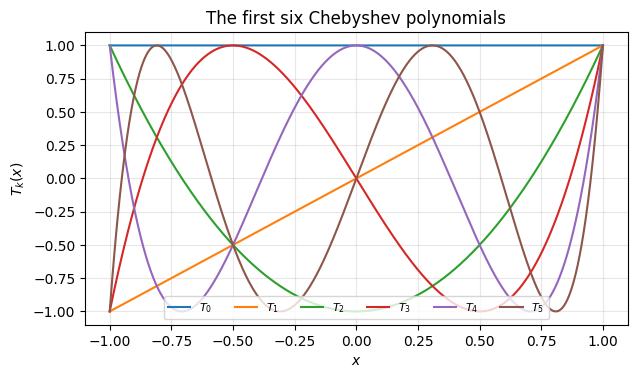

In [4]:
# ==============================================================================
# STEP 1: Chebyshev polynomials T_0..T_K on a grid, by the three-term recurrence
# ==============================================================================
def chebyshev_T(K, x):
    """All Chebyshev polynomials T_0(x), ..., T_K(x) on an array of points x.   Returns shape (K+1, len(x)).

    MATH            T_0 = 1,  T_1 = x,  T_{k+1} = 2 x T_k - T_{k-1}                  [Eq. (3)]
    IMPLEMENTATION  lax.scan with carry (T_{k-1}, T_k); the scan OUTPUT is T_{k+1}, stacked along axis 0.
    COST            O(K len(x)); numerically stable for |x| <= 1 (all values stay in [-1,1]).
    """
    x = jnp.asarray(x, dtype=RDTYPE)
    T0, T1 = jnp.ones_like(x), x

    def body(carry, _):
        T_prev, T_curr = carry
        T_next = 2 * x * T_curr - T_prev
        return (T_curr, T_next), T_next

    _, higher = lax.scan(body, (T0, T1), None, length=K - 1)
    return jnp.concatenate([T0[None], T1[None], higher], axis=0)


# ------------------------------------------------------------------------------
# CHECKPOINT: recurrence (3) versus the trigonometric definition (2)
# ------------------------------------------------------------------------------
xs = jnp.linspace(-1.0, 1.0, 2001, dtype=RDTYPE)
K_test = 200
T_rec = chebyshev_T(K_test, xs)
T_def = jnp.cos(jnp.arange(K_test + 1, dtype=RDTYPE)[:, None] * jnp.arccos(xs)[None, :])
err = float(jnp.max(jnp.abs(T_rec - T_def)))
print(f"max |T_k(recurrence) - cos(k arccos x)| for k <= {K_test}:  {err:.2e}")
assert err < 1e3 * TOL

fig, ax = plt.subplots(figsize=(7, 3.8))
for k in range(6):
    ax.plot(xs, T_rec[k], label=f"$T_{k}$")
ax.set_xlabel("$x$"); ax.set_ylabel("$T_k(x)$"); ax.set_title("The first six Chebyshev polynomials")
ax.legend(ncol=6, fontsize=8, loc="lower center"); ax.grid(alpha=0.3)
plt.show()

**Interpretation.** The recurrence reproduces $\cos(k\arccos x)$ up to rounding errors of order $10^{-13}$ even at degree 200.
The error grows **linearly** in $k$ and no faster: the printed $9\times10^{-14}$ at $k=200$ is $\approx 2k\varepsilon$ with the machine
epsilon $\varepsilon = 2.2\times10^{-16}$ (the same ratio is measured at $k=25,50,100,400$). That is the best one can hope for, and it is
the reason the whole method works: a linear recurrence amplifies earlier rounding errors by the size of its own solutions, and on $[-1,1]$
*both* solutions of $y_{k+1}=2xy_k-y_{k-1}$, namely $\cos k\theta$ and $\sin k\theta$ with $x=\cos\theta$, are bounded by 1. Nothing can grow.
(Outside $[-1,1]$ the two solutions are $\cosh k\eta$ and $\sinh k\eta$ — see (b) below.) The plot shows the
characteristic behaviour: $T_k$ oscillates between $-1$ and $+1$ exactly $k$ times and the oscillations crowd towards the end points
(equal steps in $\theta$ are unequal steps in $x=\cos\theta$).

### 3.3 Three properties we need

**(a) Boundedness.** From (2), $|T_k(x)|\le 1$ for $|x|\le1$. This is what Taylor's monomials $z^k$ lacked.

**(b) Explosion outside the interval.** For $|x|>1$ put $x=\cosh\eta$; the same algebra with hyperbolic functions gives
$T_k(x)=\cosh(k\eta)\approx \tfrac12 e^{k\eta}$: **exponential growth in $k$**. Even slightly outside, $x=1.05$ ($\eta = 0.31$),
we get $T_{100}(1.05)\approx 2.4\times10^{13}$. Keep this in mind for §8: an eigenvalue of the rescaled Hamiltonian outside $[-1,1]$ is fatal.

**(c) Orthogonality — Chebyshev series are Fourier cosine series.** Substituting $x=\cos\theta$, $dx = -\sin\theta\, d\theta = -\sqrt{1-x^2}\,d\theta$,

$$ \int_{-1}^{1} \frac{T_m(x)\,T_n(x)}{\sqrt{1-x^2}}\,dx = \int_0^{\pi}\cos m\theta\,\cos n\theta\,d\theta
   = \begin{cases} \pi & m=n=0\\ \pi/2 & m=n\neq0 \\ 0 & m\ne n .\end{cases} \qquad (4)$$

Therefore any reasonable function on $[-1,1]$ can be expanded as $f(x)=\sum_k c_k T_k(x)$, and by (4) the coefficients are

$$ c_k = \frac{2-\delta_{k0}}{\pi}\int_0^\pi f(\cos\theta)\,\cos k\theta\; d\theta . \qquad (5) $$

This is the Fourier cosine series of the $2\pi$-periodic, even function $g(\theta) = f(\cos\theta)$.
Everything known about Fourier series carries over: the smoother $f$, the faster $c_k\to0$; for functions analytic in the whole
complex plane — like $e^{-izx}$ — the decay is faster than any exponential. In particular, once $\sum_k|c_k|$ converges the series
converges *uniformly* and its sum is $f$ again, so writing $f=\sum_kc_kT_k$ is legitimate and the error of stopping at $k=K$ is at
most the sum of the omitted $|c_k|$. That is the only convergence statement we need, and §4 will make $\sum_k|c_k|$ visibly finite.

In [5]:
# ------------------------------------------------------------------------------
# CHECKPOINT: property (b) and the orthogonality relation (4)
# ------------------------------------------------------------------------------
print("growth outside [-1,1]:  T_k(1.05) =",
      ", ".join(f"{float(chebyshev_T(100, jnp.array([1.05]))[k, 0]):.2e} (k={k})" for k in (10, 50, 100)))
print(f"                        cosh(100 arccosh 1.05) = {np.cosh(100 * np.arccosh(1.05)):.2e}")

# Midpoint rule in theta: for trigonometric polynomials it is EXACT (up to rounding) once M exceeds the degree.
M = 64
theta = np.pi * (np.arange(M) + 0.5) / M
Tm = np.asarray(chebyshev_T(8, np.cos(theta)))                 # shape (9, M):  T_m(cos theta_j)
gram = (Tm @ Tm.T) * (np.pi / M)                               # Gram matrix  int_0^pi cos(m th) cos(n th) d th
expected = np.diag([np.pi] + [np.pi / 2] * 8)
print(f"orthogonality: max |Gram - diag(pi, pi/2, ...)| = {np.max(np.abs(gram - expected)):.2e}")
assert np.max(np.abs(gram - expected)) < 1e3 * TOL

growth outside [-1,1]:  T_k(1.05) = 1.17e+01 (k=10), 3.45e+06 (k=50), 2.38e+13 (k=100)
                        cosh(100 arccosh 1.05) = 2.38e+13


orthogonality: max |Gram - diag(pi, pi/2, ...)| = 4.44e-16


> **Numerical practice.** The midpoint (or trapezoidal) rule converges *exponentially* fast for smooth periodic integrands (Trefethen and Weideman 2014) —
> much better than its textbook $\mathcal{O}(h^2)$, which is the worst case for non-periodic functions. We will use it again
> in the next section to compute Bessel functions from their integral definition.

## 4. Bessel functions: the Chebyshev coefficients of a plane wave

We now apply (5) to the function we care about, $f(x)=e^{-izx}$ with a real parameter $z$ (soon: $z = at$):

$$ c_k(z) = \frac{2-\delta_{k0}}{\pi}\int_0^\pi e^{-iz\cos\theta}\,\cos k\theta\;d\theta . $$

This integral cannot be expressed by elementary functions. It is so common in physics (diffraction by a circular aperture,
vibrations of a drum, frequency modulation, cylindrical wave guides, ...) that it has a name. The **Bessel function of the first
kind of integer order $k$** is

$$ J_k(z) \;=\; \frac{i^{-k}}{\pi}\int_0^{\pi} e^{\,iz\cos\theta}\cos k\theta\;d\theta
           \;=\; \frac1\pi\int_0^\pi \cos\big(k\theta - z\sin\theta\big)\,d\theta  \qquad (6)$$

(Abramowitz & Stegun 9.1.21 states both integral representations as one equation; we quote their equivalence without proof and check it
numerically below). $J_k(z)$ is real for real $z$ and obeys $J_k(-z) = (-1)^kJ_k(z)$. Replacing $z\to -z$ in (6):

$$ \int_0^\pi e^{-iz\cos\theta}\cos k\theta\, d\theta = \pi\, i^{k} J_k(-z) = \pi\,(-i)^k J_k(z)
   \qquad\Longrightarrow\qquad \boxed{\,c_k(z) = (2-\delta_{k0})\,(-i)^k\,J_k(z)\,} \qquad (7)$$

What do these functions look like? Three facts (the first follows from (6); the others are quoted from Abramowitz & Stegun 9.1.62 — for real $z$, which is all we need — and 9.3):

* $J_k(0)=\delta_{k0}$: at $t=0$ only $c_0 = 1$ survives, as it must ($e^{0}=1=T_0$).
* $|J_k(z)|\le \dfrac{(|z|/2)^k}{k!}$: for fixed $z$ the coefficients eventually decay **faster than exponentially** in $k$.
  Stirling's estimate $k!\ge(k/e)^k$ turns this into the form worth remembering, $|J_k(z)|\le\big(e|z|/2k\big)^{k}$ — a bound that drops
  below 1 as soon as $k> e|z|/2\approx1.36\,|z|$ and then falls off a cliff, each further unit of $k$ multiplying it by roughly $e|z|/(2k)$.
  It is a *sufficient* condition, not a sharp one: the true decay already sets in at $k\approx|z|$, as the figure below shows.
* As a function of the order $k$ at fixed $z$: for $k<z$, $J_k(z)$ oscillates with amplitude $\sim\sqrt{2/(\pi z)}$; around
  $k\approx z$ there is a transition region of width $\sim z^{1/3}$; for $k>z$ the super-exponential decay sets in.

### From formula to code
We compute $J_k(z)$ in two independent ways: (i) from the definition (6) with the midpoint rule of §3 (a few lines of NumPy,
vectorised over $k$), and (ii) with the library routine `scipy.special.jv` (library routines of this kind are described in Press *et al.* 2007, §6.5). In production we use (ii); (i) is our checkpoint
that we understood the definition (and the library's conventions).

In [6]:
# ==============================================================================
# STEP 2: Bessel functions J_k(z) from their integral definition, vs scipy
# ==============================================================================
from scipy.special import jv          # J_v(z), the library implementation


def bessel_J_quadrature(K, z, M=1024):
    """J_0(z), ..., J_K(z) from the integral definition, Eq. (6), by the midpoint rule in theta.

    MATH            J_k(z) = Re[ i^{-k} / pi * int_0^pi exp(i z cos th) cos(k th) d th ]
    IMPLEMENTATION  theta_j = pi (j+1/2)/M ;  the integrand is an even 2pi-periodic trigonometric function, so the
                    midpoint rule is exponentially accurate as long as  2M - k  is well above |z|.
    COST            O(K M) -- set-up code, plain NumPy (this never runs inside the time-evolution loop).
    """
    theta = np.pi * (np.arange(M) + 0.5) / M
    k = np.arange(K + 1)
    integrand = np.exp(1j * z * np.cos(theta))[None, :] * np.cos(k[:, None] * theta[None, :])
    return np.real((1j) ** (-k) * integrand.sum(axis=1) / M)


# ------------------------------------------------------------------------------
# CHECKPOINT: both integral forms of Eq. (6) against the library
# ------------------------------------------------------------------------------
for z_chk in (0.5, 5.0, 20.0, 50.0):
    K_chk = 120
    Jq = bessel_J_quadrature(K_chk, z_chk)
    th = np.pi * (np.arange(1024) + 0.5) / 1024
    Jq2 = np.array([np.mean(np.cos(k * th - z_chk * np.sin(th))) for k in range(K_chk + 1)])   # second form of (6)
    Js = jv(np.arange(K_chk + 1), z_chk)
    e1, e2 = np.max(np.abs(Jq - Js)), np.max(np.abs(Jq2 - Js))
    print(f"z = {z_chk:5.1f}:  max_k |J_k(quadrature, form 1) - scipy| = {e1:.1e},   form 2: {e2:.1e}")
    assert max(e1, e2) < 1e3 * TOL

z =   0.5:  max_k |J_k(quadrature, form 1) - scipy| = 5.4e-16,   form 2: 7.7e-16
z =   5.0:  max_k |J_k(quadrature, form 1) - scipy| = 6.7e-16,   form 2: 9.8e-16
z =  20.0:  max_k |J_k(quadrature, form 1) - scipy| = 6.2e-16,   form 2: 8.0e-16
z =  50.0:  max_k |J_k(quadrature, form 1) - scipy| = 5.4e-16,   form 2: 7.6e-16


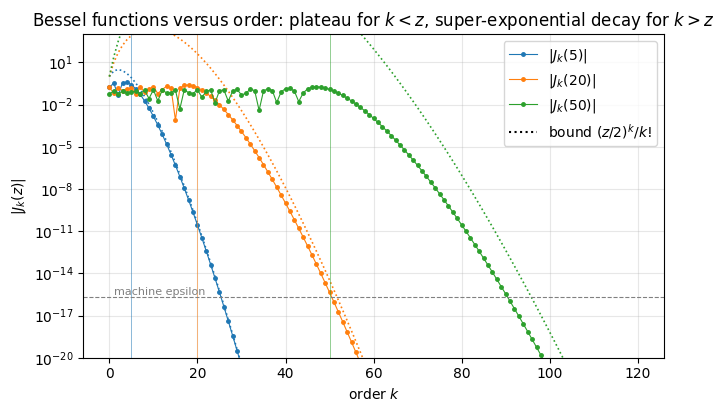

In [7]:
# ==============================================================================
# FIGURE: |J_k(z)| as a function of the order k  -- the decay that makes the method work
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ks = np.arange(0, 121)
for col, z_plot in zip(("C0", "C1", "C2"), (5.0, 20.0, 50.0)):
    ax.semilogy(ks, np.abs(jv(ks, z_plot)) + 1e-300, "o-", ms=2.5, lw=0.8, color=col, label=f"$|J_k({z_plot:g})|$")
    logbound = ks * np.log(z_plot / 2) - np.array([np.sum(np.log(np.arange(1, k + 1))) for k in ks])
    ax.semilogy(ks, np.exp(logbound), ":", color=col, lw=1.2)
    ax.axvline(z_plot, color=col, lw=0.6, alpha=0.6)
ax.plot([], [], "k:", label=r"bound $(z/2)^k/k!$")
ax.axhline(np.finfo(float).eps, color="gray", lw=0.8, ls="--"); ax.text(1, 3e-16, "machine epsilon", fontsize=8, color="gray")
ax.set_ylim(1e-20, 1e3); ax.set_xlabel("order $k$"); ax.set_ylabel("$|J_k(z)|$")
ax.set_title("Bessel functions versus order: plateau for $k<z$, super-exponential decay for $k>z$")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

**Interpretation.** Our twenty-line quadrature agrees with SciPy to $\sim10^{-16}$: definition (6) and the library convention are
the same function. The figure shows the mechanism on which the method rests. For each $z$ (vertical line) the coefficients
are of order $z^{-1/2}$ as long as $k<z$ — *all of these terms are needed* — and then fall off a cliff: within a few tens of orders
beyond $k=z$ they are below the machine epsilon $2.2\times10^{-16}$. The dotted bound $(z/2)^k/k!$ is very pessimistic near $k \approx z$
but captures the eventual factorial decay.

> **Physics insight.** Why $k\approx z$? $T_k(\cos\theta)=\cos k\theta$ oscillates with "frequency" $k$ in $\theta$, whereas $e^{-iz\cos\theta}$ has local
> frequency $|d(z\cos\theta)/d\theta| = z|\sin\theta| \le z$. A signal whose highest frequency is $z$ needs Fourier modes up to $k\approx z$ and
> essentially nothing beyond: this is the sampling theorem. In our application $z = at$ = (half the spectral width) $\times$ (time): **the number of
> $H$-applications is set by the largest phase $e^{-iEt}$ that any eigenstate can accumulate** — and no method based on polynomials in $H$ can beat that scaling.

## 5. The Jacobi–Anger identity for scalar arguments

Inserting the coefficients (7) into the Chebyshev series gives the **Jacobi–Anger expansion**

$$ \boxed{\; e^{-izx} \;=\; \sum_{k=0}^{\infty} (2-\delta_{k0})\,(-i)^k\,J_k(z)\;T_k(x), \qquad x\in[-1,1] \;} \qquad (8)$$

(with $x = \cos\theta$ this is the textbook form $e^{-iz\cos\theta} = \sum_{k=-\infty}^{\infty}(-i)^kJ_k(z)\,e^{ik\theta}$).
Truncating after $k=K$ leaves an error bounded by the omitted coefficients, since $|T_k|\le1$:

$$ \Big|e^{-izx} - \sum_{k=0}^{K} c_k T_k(x)\Big| \;\le\; 2\sum_{k>K}|J_k(z)| . \qquad (9)$$

Because of the cliff in the last figure the sum is dominated by its first few terms.

Before touching any quantum state we test (8) and (9) on plain numbers: a grid of $x\in[-1,1]$, several $z$, and we
compare with the Taylor polynomial of the same degree.

**From formula to code.** `chebyshev_T(K, xs)` has shape `(K+1, n_x)`; the coefficient vector has shape `(K+1,)`. All
partial sums at once are a cumulative sum over the first axis: `cumsum(c[:, None] * T, axis=0)[K]` is the truncation after $K$.

z =   5.0:  Chebyshev reaches 1e-12 at K =  21  (K - z =  16.0);   floor = 7.3e-16;   best Taylor error = 6.0e-15
z =  20.0:  Chebyshev reaches 1e-12 at K =  45  (K - z =  25.0);   floor = 2.8e-15;   best Taylor error = 1.4e-08
z =  50.0:  Chebyshev reaches 1e-12 at K =  83  (K - z =  33.0);   floor = 4.9e-15;   best Taylor error = 2.0e+00


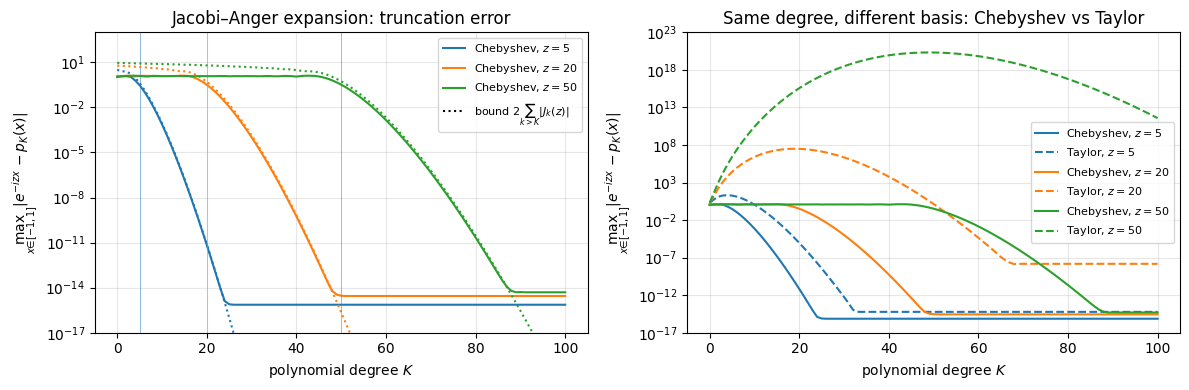

In [8]:
# ==============================================================================
# STEP 3: Jacobi-Anger coefficients and the scalar convergence test
# ==============================================================================
def jacobi_anger_coefficients(z, K):
    """c_k(z) = (2 - delta_k0) (-i)^k J_k(z)  for k = 0..K      [Eq. (7)]      (NumPy, set-up code)."""
    k = np.arange(K + 1)
    return np.where(k == 0, 1.0, 2.0) * (-1j) ** k * jv(k, z)


xs_np = np.linspace(-1, 1, 1001)
K_max = 100
T_grid = np.asarray(chebyshev_T(K_max, xs_np))                       # (K_max+1, n_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, z_val in zip(("C0", "C1", "C2"), (5.0, 20.0, 50.0)):
    target = np.exp(-1j * z_val * xs_np)
    # --- Chebyshev partial sums for every K at once
    c = jacobi_anger_coefficients(z_val, K_max)
    partial_sums = np.cumsum(c[:, None] * T_grid, axis=0)             # [K, x] = sum_{k<=K} c_k T_k(x)
    err_cheb = np.max(np.abs(partial_sums - target[None, :]), axis=1)
    # --- bound (9):  2 sum_{k>K} |J_k|
    Jabs = np.abs(jv(np.arange(K_max + 60), z_val))
    tail = np.cumsum(Jabs[::-1])[::-1]                                # tail[k] = sum_{j>=k} |J_j|   (summed from the small end)
    bound = 2 * tail[1:K_max + 2]                                     # bound[K] = 2 sum_{j>K} |J_j|
    # --- Taylor partial sums of the same degree
    taylor_coeff = np.cumprod(np.concatenate([[1.0 + 0j], -1j * z_val / np.arange(1, K_max + 1)]))   # (-iz)^k/k!
    taylor_sums = np.cumsum(taylor_coeff[:, None] * xs_np[None, :] ** np.arange(K_max + 1)[:, None], axis=0)
    err_taylor = np.max(np.abs(taylor_sums - target[None, :]), axis=1)

    axes[0].semilogy(err_cheb, "-", color=col, label=f"Chebyshev, $z={z_val:g}$")
    axes[0].semilogy(bound + 1e-300, ":", color=col)
    axes[0].axvline(z_val, color=col, lw=0.6, alpha=0.6)
    axes[1].semilogy(err_cheb, "-", color=col, label=f"Chebyshev, $z={z_val:g}$")
    axes[1].semilogy(err_taylor, "--", color=col, label=f"Taylor, $z={z_val:g}$")
    K_needed = int(np.argmax(err_cheb < 1e-12))
    print(f"z = {z_val:5.1f}:  Chebyshev reaches 1e-12 at K = {K_needed:3d}  (K - z = {K_needed - z_val:5.1f});   "
          f"floor = {err_cheb.min():.1e};   best Taylor error = {err_taylor.min():.1e}")
    assert err_cheb.min() < 1e3 * TOL

axes[0].plot([], [], "k:", label=r"bound $2\sum_{k>K}|J_k(z)|$")
for ax in axes:
    ax.set_xlabel("polynomial degree $K$"); ax.grid(alpha=0.3)
    ax.set_ylabel(r"$\max_{x\in[-1,1]}|e^{-izx} - p_K(x)|$"); ax.legend(fontsize=8)
axes[0].set_ylim(1e-17, 1e3); axes[1].set_ylim(1e-17, 1e23)
axes[0].set_title("Jacobi–Anger expansion: truncation error")
axes[1].set_title("Same degree, different basis: Chebyshev vs Taylor")
plt.tight_layout(); plt.show()

**Interpretation.**

* *Left.* Nothing happens until $K\approx z$ (vertical lines) — a polynomial of lower degree simply cannot oscillate fast enough — and then
  the error collapses to the rounding floor $\sim10^{-15}$; an accuracy of $10^{-12}$ is reached 16, 25 and 33 terms beyond $K=z$ for $z=5,20,50$. The rigorous bound (9) (dotted) follows
  the measured error closely: **the size of the first omitted Bessel coefficient is a reliable error estimate**, available before
  the calculation starts.
* *Right.* The Taylor polynomial of the same degree needs considerably more terms to start converging and, worse, its error
  saturates: at $\sim10^{-14}$ for $z=5$ (harmless), at $\sim10^{-8}$ for $z=20$, and for $z=50$ its partial sums first climb to $10^{20}$ and the final error never gets below $\mathcal O(1)$ — not a single correct digit: the cancellation problem of §2.
  The Chebyshev sum has no such problem because every term is bounded by $|c_k T_k|\le2|J_k|\le 2$.

> **Common pitfall.** The expansion (8) holds for $x\in[-1,1]$ only. For $|x|>1$ the series still converges mathematically, but the terms
> $J_k(z)T_k(x)$ first grow enormously (property (b) of §3.3) and the truncated sum is garbage. We return to this in §8.

## 6. The number of terms, $K \approx z + c\,z^{1/3}$

For a tolerance `tol` we define $K(z,\text{tol})$ as the largest order with $|J_k(z)| \ge \text{tol}$ — all later coefficients are dropped.
The transition region of $J_k(z)$ around $k = z$ has a width $\propto z^{1/3}$ (A&S 9.3: for $k\approx z$ the Bessel function turns into an
Airy function of the variable $(k-z)/(z/2)^{1/3}$), which suggests

$$ K(z,\text{tol}) \;\approx\; z + c(\text{tol})\; z^{1/3} . \qquad (10)$$

The Airy picture also predicts how $c$ depends on the tolerance. Writing $k = z + c\,z^{1/3}$, the Airy argument is $y=2^{1/3}c$, and
$\mathrm{Ai}(y)$ decays as $e^{-\frac23 y^{3/2}}$; setting that equal to `tol` and solving for $c$ gives

$$ c(\text{tol}) \;\approx\; \Big(\frac{3}{2\sqrt2}\,\ln\frac{1}{\text{tol}}\Big)^{2/3} \;=\; 4.6,\;7.3,\;10.0 \quad\text{for}\quad \text{tol}=10^{-4},10^{-8},10^{-13}. \qquad (10a)$$

Two consequences determine the cost of the method: the overhead over the unavoidable $z$ grows only as
$z^{1/3}$, and the price of extra digits grows only as $(\log_{10}(1/\text{tol}))^{2/3}$. We now measure both.

tol =   1e-04:  fitted c =  3.42;   K(z=10) =  18,   K(z=100) = 116,   K(z=300) = 322
tol =   1e-08:  fitted c =  6.36;   K(z=10) =  24,   K(z=100) = 130,   K(z=300) = 342
tol =   1e-13:  fitted c =  9.35;   K(z=10) =  31,   K(z=100) = 143,   K(z=300) = 362


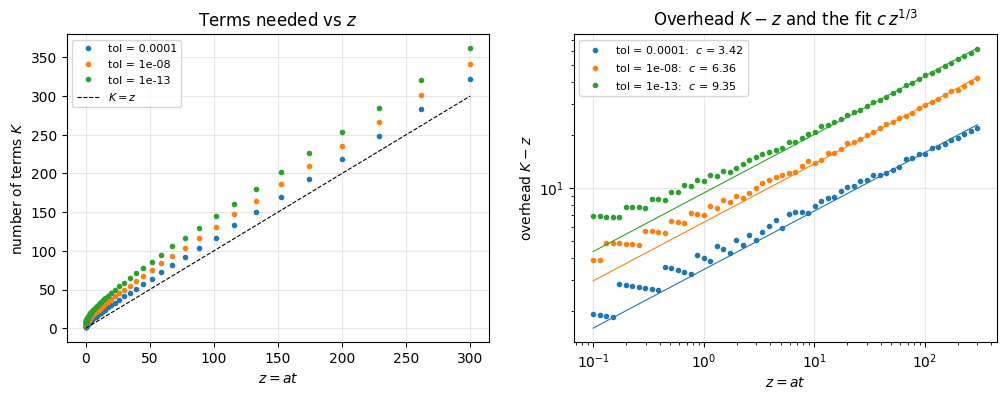

sum rule  J_0^2 + 2 sum_k J_k^2 = 0.999999999999999   (z = 37.3, 69 terms)


In [9]:
# ==============================================================================
# STEP 4: the number of Chebyshev terms needed for a given z = a*t and tolerance
# ==============================================================================
def chebyshev_coefficients(z, tol=1e-13):
    """Truncated Jacobi-Anger coefficients  c_k = (2-delta_k0)(-i)^k J_k(z),  k = 0..K,
    where K is the LAST order with |J_k(z)| >= tol  (everything beyond is below tol and is dropped).

    MATH            Eq. (7) + truncation rule of Eq. (9): error <~ 2 sum_{k>K} |J_k(z)| ~ tol.
    IMPLEMENTATION  evaluate J_k on a generous range k <= |z| + 12|z|^(1/3) + 40, then cut.  z may be negative
                    (backward evolution): J_k(-z) = (-1)^k J_k(z) is handled by scipy.
    COST            O(K) -- set-up code in NumPy/SciPy, executed once per time step SIZE (not per step).
    """
    k_hi = int(abs(z) + 12 * abs(z) ** (1 / 3) + 40)
    J = jv(np.arange(k_hi + 1), z)
    assert abs(J[-1]) < tol, "increase k_hi"
    K = max(1, int(np.max(np.nonzero(np.abs(J) >= tol)[0], initial=1)))
    k = np.arange(K + 1)
    return np.where(k == 0, 1.0, 2.0) * (-1j) ** k * J[:K + 1]


z_grid = np.unique(np.round(np.logspace(-1, np.log10(300), 60), 3))
tols = (1e-4, 1e-8, 1e-13)
K_of_z = {tol: np.array([len(chebyshev_coefficients(z, tol)) - 1 for z in z_grid]) for tol in tols}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, tol in zip(("C0", "C1", "C2"), tols):
    K_arr = K_of_z[tol]
    big = z_grid > 5
    c_fit = np.sum((K_arr - z_grid)[big] * z_grid[big] ** (1 / 3)) / np.sum(z_grid[big] ** (2 / 3))   # least squares for c
    axes[0].plot(z_grid, K_arr, "o", ms=3, color=col, label=f"tol = {tol:g}")
    axes[1].loglog(z_grid, np.maximum(K_arr - z_grid, 0.5), "o", ms=3, color=col, label=f"tol = {tol:g}:  $c$ = {c_fit:.2f}")
    axes[1].loglog(z_grid, c_fit * z_grid ** (1 / 3), "-", color=col, lw=0.8)
    print(f"tol = {tol:7.0e}:  fitted c = {c_fit:5.2f};   K(z=10) = {len(chebyshev_coefficients(10.0, tol)) - 1:3d},   "
          f"K(z=100) = {len(chebyshev_coefficients(100.0, tol)) - 1:3d},   K(z=300) = {len(chebyshev_coefficients(300.0, tol)) - 1:3d}")
axes[0].plot(z_grid, z_grid, "k--", lw=0.8, label="$K = z$")
axes[0].set_xlabel("$z = a t$"); axes[0].set_ylabel("number of terms $K$"); axes[0].set_title("Terms needed vs $z$")
axes[1].set_xlabel("$z = a t$"); axes[1].set_ylabel("overhead $K - z$"); axes[1].set_title(r"Overhead $K - z$ and the fit $c\,z^{1/3}$")
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

# sum rule (Parseval / unitarity):  |c_0|^2 + (1/2) sum_{k>=1} |c_k|^2 = J_0^2 + 2 sum J_k^2 = 1
c = chebyshev_coefficients(37.3)
sum_rule = abs(c[0]) ** 2 + 0.5 * np.sum(np.abs(c[1:]) ** 2)
print(f"sum rule  J_0^2 + 2 sum_k J_k^2 = {sum_rule:.15f}   (z = 37.3, {len(c) - 1} terms)")
assert abs(sum_rule - 1) < 1e3 * TOL

**Interpretation.** For large $z$ the number of terms is $z$ plus a *sub-linear* overhead that follows the $z^{1/3}$ law (solid lines,
right panel; for $z\lesssim 1$ the asymptotic law does not apply and the overhead levels off at a few terms). The fitted constants
$c = 3.42,\,6.36,\,9.35$ sit 7–25 % below the Airy prediction (10a) ($4.6,\,7.3,\,10.0$), which ignores the algebraic prefactor of
$\mathrm{Ai}$ and is therefore slightly conservative; the $(\ln 1/\text{tol})^{2/3}$ growth is reproduced. In practice:

* **Accuracy is almost free.** At $z=100$, going from `tol`$=10^{-4}$ to $10^{-13}$ increases $K$ only from 116 to 143 — 23 % more work for nine more digits.
  Compare: a second-order Trotter scheme pays a factor $10^{4.5}\approx 30\,000$ for the same improvement.
* **Cost is linear in time and in the spectral half-width $a$.** Since $a\propto N$ for a chain with short-range couplings, a
  Chebyshev evolution to time $t$ costs $\sim a\,t \propto N t$ applications of $H$, each of which costs $\mathcal{O}(N2^N)$.
* **Large steps are more efficient than small ones**: the overhead $c\,z^{1/3}$ is paid once per step (more in §13).

The last printed line checks the sum rule $J_0^2+2\sum_{k\ge1}J_k^2=1$, which is Parseval's theorem for the Fourier series of the unimodular function
$e^{-iz\cos\theta}$ — it expresses that the *exact* expansion is unitary.

## 7. From numbers to operators

### 7.1 Functions of a Hermitian matrix

Let $H=\sum_n E_n|n\rangle\langle n| = V\,\mathrm{diag}(E)\,V^\dagger$. Powers act on the eigenvalues, $H^k=V\,\mathrm{diag}(E^k)\,V^\dagger$ (because $V^\dagger V=1$), hence for
every polynomial $p(H)=V\,\mathrm{diag}\big(p(E_n)\big)V^\dagger$, and *by definition* $f(H)=V\,\mathrm{diag}\big(f(E_n)\big)V^\dagger$ for a general function —
in particular $e^{-iHt}$ (this is the exact propagator of [Time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb)). Any identity between functions that holds at all the eigenvalues therefore
holds for the matrices. The Jacobi–Anger identity (8) holds for $x\in[-1,1]$; we only have to bring the eigenvalues there.

### 7.2 Spectral rescaling

Let the spectrum be contained in $[E_{\min},E_{\max}]$ and define the **half-width** and the **centre**

$$ a=\frac{E_{\max}-E_{\min}}{2},\qquad b=\frac{E_{\max}+E_{\min}}{2},\qquad \tilde H=\frac{H-b}{a}\quad\Rightarrow\quad \mathrm{spec}(\tilde H)\subset[-1,1]. $$

Then $H=a\tilde H+b$ and, since the number $b$ commutes with everything,

$$ e^{-iHt}=e^{-ibt}\,e^{-i(at)\tilde H}
   \;=\; e^{-ibt}\sum_{k=0}^{\infty}c_k(at)\;T_k(\tilde H),\qquad c_k(z) = (2-\delta_{k0})(-i)^kJ_k(z). \qquad (11)$$

Acting on a state and defining the **Chebyshev vectors** $|\phi_k\rangle = T_k(\tilde H)|\psi\rangle$, the recurrence (3) becomes

$$ |\phi_0\rangle=|\psi\rangle,\qquad |\phi_1\rangle=\tilde H|\psi\rangle,\qquad |\phi_{k+1}\rangle=2\tilde H|\phi_k\rangle-|\phi_{k-1}\rangle,
   \qquad |\psi(t)\rangle \approx e^{-ibt}\sum_{k=0}^{K}c_k(at)\,|\phi_k\rangle . \qquad (12)$$

**One application of $H$ per term, three state vectors of memory** ($\phi_{k-1}$, $\phi_k$ and the accumulated sum; plus one temporary). No matrix is ever formed, and the
polynomials $T_k(\tilde H)$ are never formed either — only their action on one vector.

By Eq. (1), the error of the truncated operator series *in operator norm* is the scalar error of §5: everything we learned there
carries over with $z=at$.

### 7.3 Dense validation on a small chain

Throughout the notebook we use a spin chain that has no special simplifying structure (it is *non-integrable*): the XXZ chain in a transverse field,

$$ H=\sum_{j=0}^{N-2}\big(J_{xx}X_jX_{j+1}+J_{yy}Y_jY_{j+1}+J_{zz}Z_jZ_{j+1}\big)+h_x\sum_{j=0}^{N-1}X_j,
   \qquad J_{xx}=J_{yy}=1,\; J_{zz}=0.5,\; h_x=1, $$

in the Pauli convention, with open boundaries. For $N=6$ ($64\times64$ matrices) we can afford to build everything densely and check (11) term by term:
(i) the matrix recurrence against $T_k(\tilde H)=V\cos\!\big(k\arccos\tilde E\big)V^\dagger$; (ii) the truncated sum against the exact propagator.

In [10]:
# ==============================================================================
# PARAMETERS of the model used in the whole notebook
# ==============================================================================
JXX, JYY, JZZ, HX = 1.0, 1.0, 0.5, 1.0          # XXZ couplings and transverse field (Pauli convention)


def model_terms(N):
    """List of local terms of  H = sum_j (Jxx XX + Jyy YY + Jzz ZZ)_{j,j+1} + hx sum_j X_j  (open chain)."""
    return heisenberg_terms(N, Jxx=JXX, Jyy=JYY, Jzz=JZZ, hx=HX)


# ==============================================================================
# VALIDATION CELL (dense matrices, small N only): Eq. (11) as a matrix identity
# ==============================================================================
N_small, t_small = 6, 1.5
H_dense = dense_hamiltonian(model_terms(N_small), N_small)               # 64 x 64
E, V = jnp.linalg.eigh(H_dense)
a_ex, b_ex = float(E[-1] - E[0]) / 2, float(E[-1] + E[0]) / 2
Ht_dense = (H_dense - b_ex * jnp.eye(2 ** N_small, dtype=CDTYPE)) / a_ex
E_tilde = jnp.clip((E - b_ex) / a_ex, -1.0, 1.0)                         # rescaled eigenvalues (clip guards rounding at +-1)
print(f"N = {N_small}: spectrum in [{float(E[0]):.4f}, {float(E[-1]):.4f}]  ->  a = {a_ex:.4f}, b = {b_ex:.4f},  z = a t = {a_ex * t_small:.2f}")

U_exact = (V * jnp.exp(-1j * t_small * E)) @ V.conj().T                  # V exp(-iEt) V^dagger
coef = jacobi_anger_coefficients(a_ex * t_small, 60)

T_prev, T_curr = jnp.eye(2 ** N_small, dtype=CDTYPE), Ht_dense
U_sum = coef[0] * T_prev + coef[1] * T_curr
err_poly, err_U = [], [float(jnp.linalg.norm(jnp.exp(-1j * b_ex * t_small) * (coef[0] * T_prev) - U_exact, 2)),
                       float(jnp.linalg.norm(jnp.exp(-1j * b_ex * t_small) * U_sum - U_exact, 2))]
for k in range(2, 61):
    T_prev, T_curr = T_curr, 2 * Ht_dense @ T_curr - T_prev              # matrix version of recurrence (3)
    T_spectral = (V * jnp.cos(k * jnp.arccos(E_tilde))) @ V.conj().T     # V cos(k arccos E~) V^dagger
    err_poly.append(float(jnp.max(jnp.abs(T_curr - T_spectral))))
    U_sum = U_sum + coef[k] * T_curr
    err_U.append(float(jnp.linalg.norm(jnp.exp(-1j * b_ex * t_small) * U_sum - U_exact, 2)))   # operator 2-norm

print(f"(i)  max_k max_ij |T_k(H~) by recurrence - V cos(k arccos E~) V^+| = {max(err_poly):.2e}")
print(f"(ii) || e^(-ibt) sum_(k<=K) c_k T_k(H~) - exp(-iHt) ||_2 :  "
      + ",  ".join(f"K={K}: {err_U[K]:.1e}" for K in (5, 10, 15, 20, 25, 30, 40)))
assert max(err_poly) < 1e3 * TOL and min(err_U) < 1e2 * TOL

N = 6: spectrum in [-8.6543, 11.1927]  ->  a = 9.9235, b = 1.2692,  z = a t = 14.89


(i)  max_k max_ij |T_k(H~) by recurrence - V cos(k arccos E~) V^+| = 5.73e-14
(ii) || e^(-ibt) sum_(k<=K) c_k T_k(H~) - exp(-iHt) ||_2 :  K=5: 1.2e+00,  K=10: 1.3e+00,  K=15: 3.0e-01,  K=20: 6.2e-03,  K=25: 2.9e-05,  K=30: 4.6e-08,  K=40: 1.8e-14


**Interpretation.** (i) The matrix recurrence produces exactly the matrix function $T_k(\tilde H)$ defined through the eigen-decomposition — the polynomial identity
lifts from numbers to operators. (ii) With $z=at\approx 15$ the operator-norm error is still $\mathcal O(1)$ at $K=15$ and falls to the $10^{-14}$ level by $K\approx 40$,
just as the scalar theory (Fig. of §5) predicts for this $z$. This is a statement about the *whole propagator*: it holds for every initial state at once.

### 7.4 The same recurrence for any function of $H$

Nothing in the recurrence (12) knows about $e^{-izx}$. Only the coefficients $c_k$ do, and they come from one integral, Eq. (5). Changing that
integral gives a different function of $H$ for the same code and the same cost. Two cases are standard.

* **Imaginary time.** For $f(x)=e^{-\tau a x}$ the integral (5) is the standard representation of the *modified* Bessel function,
  $\int_0^\pi e^{w\cos\theta}\cos k\theta\,d\theta = \pi I_k(w)$, so $c_k=(2-\delta_{k0})(-1)^kI_k(\tau a)$ and $e^{-\tau H}=e^{-\tau b}\sum_kc_kT_k(\tilde H)$.
  Applied to a random state and normalised, this projects onto the ground state — an alternative to Lanczos (Exercise 5).
* **Spectral functions and the kernel polynomial method.** Densities of states, $\rho(E)=\sum_n\delta(E-E_n)$, and spectral functions are expanded in exactly the
  same basis after exactly the same rescaling; the method is called the **kernel polynomial method** (Weiße *et al.*, Rev. Mod. Phys. 2006). The one structural
  difference is decisive: $\delta$- and step functions are not smooth, so by §3.3 their Chebyshev coefficients decay only algebraically, the truncated series
  oscillates (the Gibbs phenomenon), and one multiplies $c_k$ by a *damping kernel* $g_k$ (the Jackson kernel) which trades the oscillations for a finite
  resolution $\sim a/K$. Our $e^{-ixt}$ is entire, its coefficients fall off a cliff, and no kernel is needed — which is why a Chebyshev propagator is
  *numerically exact* while a KPM spectrum is always a smoothed one.

## 8. Spectral bounds and the failure for wrong bounds

The rescaling needs $E_{\min}$ and $E_{\max}$, but computing the spectrum is exactly what we cannot afford. Two practical options:

**(A) A short Lanczos run.** As shown in [Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb), the extremal eigenvalues of the small tridiagonal
Lanczos matrix (the *Ritz values*) converge quickly to $E_{\min}$ and $E_{\max}$, using only $H|\phi\rangle$. There is a catch: Ritz values are always **inside** the true spectrum
(they are expectation values of $H$ in normalised states of the Krylov space, and $E_{\min}\le\langle H\rangle\le E_{\max}$), so Lanczos *under*-estimates the width. Hence the
**safety factor**: we enlarge the half-width, $a\to 1.02\,a$. The engine function `spectral_bounds(terms, N, m=40)` does the Lanczos part; `chebyshev_evolve` applies the safety factor.

**(B) A rigorous bound from the triangle inequality.** $\|H\|\le\sum_k\|h_k\|$, where $\|h_k\|$ is the largest $|$eigenvalue$|$ of a $4\times4$ or $2\times2$ term: costs
nothing and can never fail, but over-estimates the width — and *every* percent of over-estimation is a percent more work, because $K\approx at$.

Let us compare both with the exact spectrum at $N=10$.

In [11]:
# ==============================================================================
# STEP 5: spectral bounds -- Lanczos (A) vs triangle inequality (B) vs exact (validation, N = 10)
# ==============================================================================
def norm_bound(terms):
    """Rigorous bound  ||H|| <= sum_k ||h_k||  (largest |eigenvalue| of every local term).  Returns (-B, +B)."""
    B = sum(float(np.max(np.abs(np.linalg.eigvalsh(np.asarray(h))))) for _, h in terms)
    return -B, B


N_val = 10
terms_val = model_terms(N_val)
t0 = time.perf_counter()
E_d, V_d = jnp.linalg.eigh(dense_hamiltonian(terms_val, N_val))                  # validation only: 1024 x 1024, done ONCE
E_all = np.asarray(E_d)
t_dense = time.perf_counter() - t0


def exact_state(psi0, t):
    """Dense reference |psi(t)> = V exp(-i E t) V^+ |psi0> for the N = 10 validation chain (re-uses E_d, V_d)."""
    return (V_d @ (jnp.exp(-1j * E_d * t) * (V_d.conj().T @ psi0.reshape(-1)))).reshape(psi0.shape)


t0 = time.perf_counter()
bounds_lanczos = spectral_bounds(terms_val, N_val, m=40)
t_lanczos = time.perf_counter() - t0
bounds_norm = norm_bound(terms_val)

half_width = lambda bd: (bd[1] - bd[0]) / 2
print(f"exact spectrum  : [{E_all[0]:9.5f}, {E_all[-1]:9.5f}]   a = {half_width((E_all[0], E_all[-1])):.4f}")
print(f"(A) Lanczos m=40: [{bounds_lanczos[0]:9.5f}, {bounds_lanczos[1]:9.5f}]   a = {half_width(bounds_lanczos):.4f}"
      f"   -> inside the true spectrum by ({bounds_lanczos[0] - E_all[0]:.1e}, {E_all[-1] - bounds_lanczos[1]:.1e})")
print(f"cost: dense diagonalisation {t_dense:.2f} s,  Lanczos {t_lanczos:.2f} s   (dense scales as 8^N, Lanczos as N 2^N)")
print(f"(B) norm bound  : [{bounds_norm[0]:9.5f}, {bounds_norm[1]:9.5f}]   a = {half_width(bounds_norm):.4f}"
      f"   -> {half_width(bounds_norm) / half_width((E_all[0], E_all[-1])):.2f} x the true half-width = that many times more work")
assert bounds_lanczos[0] >= E_all[0] - 1e-8 and bounds_lanczos[1] <= E_all[-1] + 1e-8      # Ritz values lie inside
assert 1.02 * half_width(bounds_lanczos) > half_width((E_all[0], E_all[-1]))               # safety factor suffices

exact spectrum  : [-15.17846,  19.33008]   a = 17.2543
(A) Lanczos m=40: [-15.17846,  19.33008]   a = 17.2543   -> inside the true spectrum by (5.5e-09, -3.6e-15)
cost: dense diagonalisation 4.91 s,  Lanczos 2.51 s   (dense scales as 8^N, Lanczos as N 2^N)
(B) norm bound  : [-32.50000,  32.50000]   a = 32.5000   -> 1.88 x the true half-width = that many times more work


**Interpretation.** Forty Lanczos iterations give both edges to eight or more decimal places, and from *inside* the spectrum as the variational argument requires (the upper edge misses by a few $10^{-15}$
in the *other* direction, which is pure floating-point round-off, not a violation of the variational argument) — and the 2 % safety margin covers the
remaining gap with a lot of room to spare (the margin is there for harder cases: larger $N$, shorter Lanczos runs, nearly degenerate edges). The rigorous bound (B) is almost twice too wide for this model: safe, but it would make every evolution almost twice as expensive.
We use (A) with the safety factor from now on.

### An eigenvalue that leaks out of $[-1,1]$

Then for that eigenvector $T_k(\tilde E)=\cosh(k\,\mathrm{arccosh}|\tilde E|)$ grows exponentially with $k$ (property (b), §3.3) while the coefficients $J_k(at)$ stay $\mathcal O(1)$ up to $k\approx at$: the
component of the state along that eigenvector is amplified by a factor of order $e^{\,at\,\mathrm{arccosh}|\tilde E|}$ and swamps the result. We provoke this on purpose by *shrinking* the half-width
by a factor $s<1$ (so that the largest rescaled eigenvalue is $1/s$), using the engine's `chebyshev_evolve`, whose `safety` argument is exactly this factor. We try two initial states: the product state
$|0\dots0\rangle$ and a Haar-random state, and evolve to $t=5$ ($at\approx86$).

In [12]:
# ==============================================================================
# EXPERIMENT: deliberately wrong rescaling -- the blow-up outside [-1,1]      (N = 10, t = 5, exact bounds scaled by s)
# ==============================================================================
psi0_val = zero_state(N_val)                                  # |00...0> = all spins up along z
psi0_haar = haar_state(jax.random.PRNGKey(3), N_val)          # random state: overlaps with ALL eigenvectors
t_blow = 5.0
exact_bounds = (float(E_all[0]), float(E_all[-1]))

for label, psi_in in (("|00...0>", psi0_val), ("Haar-random state", psi0_haar)):
    amp = V_d.conj().T @ psi_in.reshape(-1)
    print(f"\n{label}:  overlaps with the two extremal eigenvectors  |<E_min|psi>| = {float(jnp.abs(amp[0])):.1e},  |<E_max|psi>| = {float(jnp.abs(amp[-1])):.1e}")
    print("   scale s | largest |E~| | eigenvalues outside [-1,1] |   norm - 1   | error ||psi - psi_exact|| | (norm-1)/error")
    for s in (1.5, 1.02, 1.0, 0.99, 0.98, 0.95, 0.90, 0.80):
        psi_s = chebyshev_evolve(psi_in, terms_val, t_blow, exact_bounds, safety=s)
        a_s, b_s = s * (exact_bounds[1] - exact_bounds[0]) / 2, (exact_bounds[1] + exact_bounds[0]) / 2
        n_out = int(np.sum(np.abs((E_all - b_s) / a_s) > 1 + 1e-12))
        dn = float(jnp.linalg.norm(psi_s)) - 1.0
        er = float(jnp.linalg.norm(psi_s - exact_state(psi_in, t_blow)))
        print(f"    {s:5.2f}  |    {1 / s:6.3f}    | {n_out:26d} | {dn:+12.4e} | {er:24.3e} | {abs(dn) / er:14.1e}")
        assert (er < 1e3 * TOL) if s >= 1 else True          # correct (or generous) bounds: exact state
        assert (er > 1.0) if s <= 0.9 else True              # wrong control: 10 % missing width must ruin the state


|00...0>:  overlaps with the two extremal eigenvectors  |<E_min|psi>| = 2.9e-06,  |<E_max|psi>| = 1.1e-02
   scale s | largest |E~| | eigenvalues outside [-1,1] |   norm - 1   | error ||psi - psi_exact|| | (norm-1)/error


     1.50  |     0.667    |                          0 |  +0.0000e+00 |                1.916e-14 |        0.0e+00


     1.02  |     0.980    |                          0 |  +8.8818e-16 |                1.627e-14 |        5.5e-02


     1.00  |     1.000    |                          0 |  +5.7732e-15 |                1.745e-14 |        3.3e-01


     0.99  |     1.010    |                          2 |  +1.3212e-13 |                1.363e-11 |        9.7e-03


...

     0.99  |     1.010    |                          2 |  +3.3564e-12 |                6.634e-11 |        5.1e-02


     0.98  |     1.020    |                          2 |  +4.3711e-09 |                1.624e-07 |        2.7e-02


     0.95  |     1.053    |                          3 |  +3.1398e-01 |                8.085e-01 |        3.9e-01


     0.90  |     1.111    |                          6 |  +2.3648e+09 |                2.365e+09 |        1.0e+00


     0.80  |     1.250    |                         15 |  +4.4979e+17 |                4.498e+17 |        1.0e+00


**Interpretation.** With $s\ge1$ every choice gives the exact state to $\sim10^{-14}$ — over-estimating the width (even by 50 %) is *harmless for accuracy* and only costs proportionally more terms.
With $s<1$ the method **explodes**: the error grows by many orders of magnitude for every few per cent of missing width, and a "state" with norm $\gg1$ comes out.
How fast the disaster strikes depends on the state: the damage is proportional to the overlap of $|\psi\rangle$ with the eigenvectors whose eigenvalues were left outside — only a handful at the sparse edges of a many-body spectrum, and
the product state happens to have a particularly small overlap with the lowest one. This makes the failure treacherous: slightly wrong bounds may go unnoticed in a test with one initial state or a short time, and ruin the production run with another.

### The norm as an error monitor and its limits

The truncated propagator $p_K(\tilde H)$ is a polynomial, not a unitary, so $\|\,p_K(\tilde H)|\psi\rangle\|$ is not exactly 1 and the deviation
is free information. How much information? Expand in eigenstates, $p_K(\tilde E_n)=e^{-i(E_n-b)t}+\delta_n$ with $|\delta_n|$ the scalar
error of §5, and write $A_n=\langle n|\psi\rangle$. Then

$$ \|\psi_K\|^2 - 1 = \sum_n|A_n|^2\Big(2\,\mathrm{Re}\big[e^{\,i(E_n-b)t}\delta_n\big] + |\delta_n|^2\Big), \qquad
   \|\psi_K-\psi_{\rm exact}\|^2 = \sum_n |A_n|^2|\delta_n|^2 . \qquad (9a)$$

If one eigenvalue dominates the damage — which is exactly the situation here, the one that leaked out — with amplitude $A$ and error $\delta$,
the true error is $|A||\delta|$ while the norm moves by $|A|^2\,\mathrm{Re}\big[e^{\,i(E-b)t}\delta\big]$, at most $|A|^2|\delta|$. **The norm under-reports the error by the overlap factor $|A|$**
(times the cosine of a phase), and $|A|$ is small precisely in the treacherous cases. The last column of the table measures this ratio. Read it in the rows where exactly two eigenvalues have
leaked, $s=0.99$ and $0.98$: there the ratio lies between about half the overlap printed above each block and the overlap itself ($1.1\times10^{-2}$ for the product state,
$4.4\times10^{-2}$ for the Haar state, whose lowest eigenvector contributes as well), so a norm deviation of $2\times10^{-10}$ accompanies a state that is wrong by $3\times10^{-8}$. Above those rows nothing
has leaked and both columns are pure round-off, so their ratio means nothing; below them the corruption is so large that the "state" *is* the error and the ratio
saturates at 1.

> **Common pitfall.** An exploding norm in a Chebyshev code almost always means that the spectrum is not inside $[-1,1]$: bounds taken from a *different* Hamiltonian
> (after changing a coupling, a field, or $N$), a Lanczos run that was too short, or a forgotten safety factor. **Monitor the norm** — it is a free diagnostic: for correct bounds it is conserved to $\sim10^{-13}$.
> But read it as a *lower* bound on the error: by (9a) a norm deviation $\eta$ signals an error of at least $\eta$ and typically $\eta/|A|$, which can be orders of magnitude larger.
> A norm that looks perfect to six digits is not a certificate; the safety factor and a convergence test in $K$ are.

## 9. The matrix-free implementation with `lax.scan`

We now write the production algorithm, Eq. (12), in three small pure functions.

| step | math | code | where it runs |
|---|---|---|---|
| coefficients | $c_k=(2-\delta_{k0})(-i)^kJ_k(a\,\Delta t)$, truncated at `tol` | `chebyshev_coefficients` (§6) | NumPy/SciPy, **once** per step size |
| rescaled Hamiltonian | $\tilde H\vert\phi\rangle=(H\vert\phi\rangle-b\vert\phi\rangle)/a$ | `make_scaled_matvec` | JAX, inside the loop |
| recurrence + sum | $\phi_{k+1}=2\tilde H\phi_k-\phi_{k-1}$, $\;\Sigma\leftarrow\Sigma+c_{k+1}\phi_{k+1}$ | `chebyshev_apply` (a `lax.scan`) | JAX, jit-compiled |

**How the recurrence maps onto `scan`.** The loop state (*carry*) is the triple $(\phi_{k-1},\phi_k,\Sigma)$ of rank-$N$ tensors. The thing we iterate *over* is
the coefficient array `coef[2:]`: `scan` hands the body one $c_k$ per iteration. The body performs one `apply_hamiltonian` (a sum of $\sim2N$ einsums) plus a few
element-wise operations, and returns the shifted triple. Because `scan` compiles the body **once**, the compile time is independent of $K$, and XLA can reuse the buffers
of the carry, so the memory footprint really is four state vectors.

> **JAX practice.** The Bessel coefficients are computed *outside* the compiled function and enter it as an ordinary array. This is the general pattern: set-up code that runs
> once may use any Python library (here `scipy.special`), the hot loop must be pure JAX. Consequently the *length* of `coef` is part of the array's shape, so a different
> $K$ (a different step $\Delta t$ or tolerance) triggers a re-compilation, whereas a different state or different coefficient *values* does not.

In [13]:
# ==============================================================================
# STEP 6: the Chebyshev propagator, matrix-free
# ==============================================================================
def make_scaled_matvec(terms, bounds, safety=1.02):
    """Return (Ht, a, b) with Ht(phi) = (H phi - b phi)/a  the rescaled Hamiltonian, spectrum inside [-1,1].

    MATH   a = safety * (Emax - Emin)/2   (half-width, enlarged because Lanczos bounds lie INSIDE the spectrum)
           b = (Emax + Emin)/2            (centre)
    COST   one `apply_hamiltonian` = O(#terms * 2^N); nothing of size 4^N is ever built.
    """
    E_min, E_max = bounds
    a, b = safety * (E_max - E_min) / 2.0, (E_max + E_min) / 2.0

    def Ht(phi):
        return (apply_hamiltonian(terms, phi) - b * phi) / a

    return Ht, a, b


def chebyshev_apply(Ht, psi, coef):
    """sum_{k=0}^{K} coef[k] T_k(Ht) |psi>   by the three-term recurrence, Eq. (12).

    MATH            phi_0 = psi,  phi_1 = Ht psi,  phi_{k+1} = 2 Ht phi_k - phi_{k-1};   result = sum_k c_k phi_k
    IMPLEMENTATION  lax.scan over the coefficients c_2..c_K with carry (phi_{k-1}, phi_k, partial sum).
    COST            K applications of H;  memory: 3 state vectors in the carry + 1 temporary.
    JAX             pure function of (psi, coef): jit-able, vmap-able over psi, differentiable.
    """
    phi_prev, phi_curr = psi, Ht(psi)
    acc = coef[0] * phi_prev + coef[1] * phi_curr

    def body(carry, c_k):
        phi_prev, phi_curr, acc = carry
        phi_next = 2 * Ht(phi_curr) - phi_prev
        return (phi_curr, phi_next, acc + c_k * phi_next), None

    (_, _, acc), _ = lax.scan(body, (phi_prev, phi_curr, acc), coef[2:])
    return acc


def make_chebyshev_step(terms, bounds, dt, tol=1e-13, safety=1.02):
    """Build the jit-compiled map  |psi> -> exp(-i H dt)|psi>.   Returns (step, K).

    MATH   exp(-iH dt) = exp(-i b dt) sum_k c_k(a dt) T_k(Ht),   Eq. (11), truncated where |J_k(a dt)| < tol.
    NOTE   dt is a STEP SIZE, not necessarily small: accuracy does not depend on it, only K ~ a dt does.
    """
    Ht, a, b = make_scaled_matvec(terms, bounds, safety)
    coef = jnp.asarray(chebyshev_coefficients(a * dt, tol), dtype=CDTYPE)
    phase = jnp.asarray(np.exp(-1j * b * dt), dtype=CDTYPE)
    step = jax.jit(lambda psi: phase * chebyshev_apply(Ht, psi, coef))
    return step, len(coef) - 1


# ------------------------------------------------------------------------------
# CHECKPOINT: our implementation == engine `chebyshev_evolve` == dense exact evolution   (N = 10, t = 2)
# ------------------------------------------------------------------------------
t_val = 2.0
psi_ref = exact_state(psi0_val, t_val)
step_val, K_val = make_chebyshev_step(terms_val, bounds_lanczos, t_val)
psi_ours = step_val(psi0_val)
psi_engine = chebyshev_evolve(psi0_val, terms_val, t_val, bounds_lanczos)
err_exact = float(jnp.linalg.norm(psi_ours - psi_ref))
err_engine = float(jnp.linalg.norm(psi_ours - psi_engine))
print(f"K = {K_val} applications of H   (z = a t = {1.02 * half_width(bounds_lanczos) * t_val:.1f})")
print(f"|| psi_ours - psi_exact  || = {err_exact:.2e}")
print(f"|| psi_ours - psi_engine || = {err_engine:.2e}")
print(f"norm - 1 = {float(jnp.linalg.norm(psi_ours)) - 1:+.2e}")
assert err_exact < 100 * TOL and err_engine < 100 * TOL

K = 66 applications of H   (z = a t = 35.2)
|| psi_ours - psi_exact  || = 1.04e-13
|| psi_ours - psi_engine || = 1.04e-13
norm - 1 = -5.33e-15


**Interpretation.** A single "time step" of length $t=2$ — forty times larger than a typical TEBD step — reproduces the dense exact state to $\sim10^{-13}$, i.e. to the rounding error
of double precision, using 66 applications of $H$ (for $z=at\approx35$). Our three functions agree with the engine's one-call version `chebyshev_evolve` (see the Engine recap; the engine computes its
coefficients slightly differently — it starts at $K=\lceil at\rceil+20$ and raises $K$ in steps of 10 until $|J_K(at)|<$ `tol`, keeping a few terms more than our rule, which makes no difference at this precision).

## 10. Validation: convergence to machine precision

### 10.1 The whole convergence curve from one run

How does the state error depend on the truncation order $K$? The naive experiment re-runs the propagation for every $K$ (and re-compiles each time, since the shape of `coef` changes).
A neater way uses the *outputs* of `scan`: the partial sum after $k$ terms **is** the $K=k$ approximation, so we let the body emit $\big\|e^{-ibt}\Sigma_k-\psi_{\rm exact}\big\|$ at
every iteration. One compilation, one pass, the full curve.

t = 0.5: z =   8.80;  truncation rule (tol=1e-13) gives K =  29;  error there = 5.25e-14;  floor = 2.64e-15


t = 2.0: z =  35.20;  truncation rule (tol=1e-13) gives K =  66;  error there = 1.04e-13;  floor = 8.27e-15


t = 5.0: z =  88.00;  truncation rule (tol=1e-13) gives K = 129;  error there = 1.64e-13;  floor = 1.62e-14


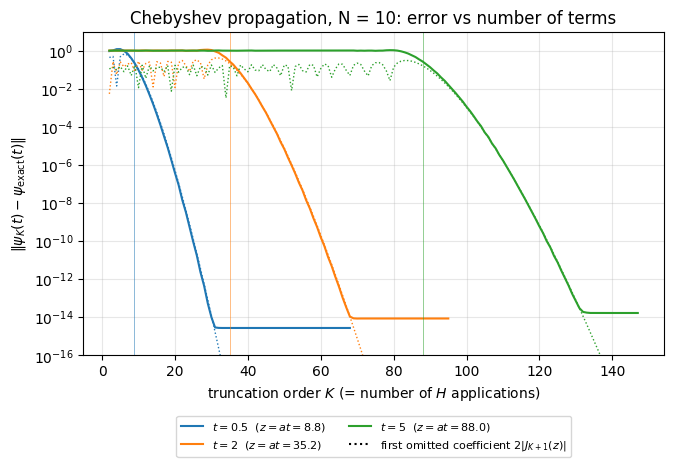

In [14]:
# ==============================================================================
# EXPERIMENT: state error versus truncation order K, all K in one scan
# ==============================================================================
def chebyshev_partial_errors(Ht, psi, coef, phase, psi_exact):
    """Same recurrence as `chebyshev_apply`, but the scan OUTPUT is the error of every partial sum:
       err[k] = || phase * sum_{j<=k} c_j phi_j  -  psi_exact ||    for k = 2..K."""
    phi_prev, phi_curr = psi, Ht(psi)
    acc = coef[0] * phi_prev + coef[1] * phi_curr

    def body(carry, c_k):
        phi_prev, phi_curr, acc = carry
        phi_next = 2 * Ht(phi_curr) - phi_prev
        acc = acc + c_k * phi_next
        return (phi_curr, phi_next, acc), jnp.linalg.norm(phase * acc - psi_exact)

    _, errs = lax.scan(body, (phi_prev, phi_curr, acc), coef[2:])
    return errs


Ht_val, a_val, b_val = make_scaled_matvec(terms_val, bounds_lanczos)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for col, t_run in zip(("C0", "C1", "C2"), (0.5, 2.0, 5.0)):
    z_run = a_val * t_run
    K_run = int(z_run + 60)
    coef_run = jnp.asarray(jacobi_anger_coefficients(z_run, K_run), dtype=CDTYPE)      # NOT truncated: we want the full curve
    exact_run = exact_state(psi0_val, t_run)
    errs = np.asarray(jax.jit(chebyshev_partial_errors, static_argnums=0)(
        Ht_val, psi0_val, coef_run, jnp.exp(-1j * b_val * t_run), exact_run))
    ax.semilogy(np.arange(2, K_run + 1), errs, "-", color=col, label=f"$t={t_run:g}$  ($z=at={z_run:.1f}$)")
    ax.semilogy(np.arange(2, K_run + 1), 2 * np.abs(jv(np.arange(3, K_run + 2), z_run)) + 1e-300, ":", color=col, lw=1)
    ax.axvline(z_run, color=col, lw=0.6, alpha=0.6)
    K_tol = len(chebyshev_coefficients(z_run, 1e-13)) - 1
    print(f"t = {t_run:3.1f}: z = {z_run:6.2f};  truncation rule (tol=1e-13) gives K = {K_tol:3d};  "
          f"error there = {errs[K_tol - 2]:.2e};  floor = {errs.min():.2e}")
    assert errs[K_tol - 2] < 100 * TOL
ax.plot([], [], "k:", label=r"first omitted coefficient $2|J_{K+1}(z)|$")
ax.set_ylim(1e-16, 10); ax.set_xlabel("truncation order $K$ (= number of $H$ applications)")
ax.set_ylabel(r"$\|\psi_K(t)-\psi_{\rm exact}(t)\|$"); ax.set_title(f"Chebyshev propagation, N = {N_val}: error vs number of terms")
ax.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.17)); ax.grid(alpha=0.3)
plt.show()

**Interpretation.** The many-body state error behaves exactly like the scalar error of §5: a plateau of size $\mathcal O(1)$ while $K<at$ (vertical lines), followed by a super-exponential
collapse onto the rounding floor of $\sim10^{-14}$. The dotted curves — just *one number*, the first omitted Bessel coefficient — predict the error of a $2^{10}$-dimensional calculation:
the truncation rule with `tol`$=10^{-13}$ stops where the curve hits the floor. There is no time-step error to extrapolate away; $t=5$ in one step is as accurate as $t=0.5$.

> **JAX practice.** `jax.jit(f, static_argnums=0)` marks the first argument (here the Python function `Ht`) as *static*: it is not an array, it is part of the program being compiled.

### 10.2 Checks that need no dense reference

A dense reference exists only for $N\lesssim12$. For larger systems we rely on *exact properties* of the evolution: (a) norm conservation (unitarity), (b) energy conservation
$\langle\psi(t)|H|\psi(t)\rangle=\text{const}$, and (c) **time reversal**: $e^{+iHt}e^{-iHt}|\psi\rangle=|\psi\rangle$ — propagating backwards only requires the coefficients for $z=-at$.
Check (c) is particularly valuable: it tests the *entire state*, not just two numbers. (A caveat: all three would also be passed by a propagator for the *wrong* Hamiltonian; they complement, not replace, the small-$N$ comparison.)

In [15]:
# ------------------------------------------------------------------------------
# CHECKPOINT at N = 14 (no dense reference): norm, energy, time reversal
# ------------------------------------------------------------------------------
N_big = 14
terms_big = model_terms(N_big)
bounds_big = spectral_bounds(terms_big, N_big)
psi0_big = zero_state(N_big)

forward, K_fwd = make_chebyshev_step(terms_big, bounds_big, +3.0)
backward, K_bwd = make_chebyshev_step(terms_big, bounds_big, -3.0)
psi_t = forward(psi0_big)
psi_back = backward(psi_t)

E0, Et = float(energy(terms_big, psi0_big)), float(energy(terms_big, psi_t))
print(f"N = {N_big}, t = 3:  K = {K_fwd} terms forward, {K_bwd} backward;  bounds = ({bounds_big[0]:.3f}, {bounds_big[1]:.3f})")
print(f"(a) norm - 1                     = {float(jnp.linalg.norm(psi_t)) - 1:+.2e}")
print(f"(b) energy: E(0) = {E0:.12f},  E(t) - E(0) = {Et - E0:+.2e}")
print(f"(c) || U(-t) U(t) psi0 - psi0 || = {float(jnp.linalg.norm(psi_back - psi0_big)):.2e}")
print(f"    overlap |<psi0|psi(t)>|^2    = {float(jnp.abs(jnp.vdot(psi0_big, psi_t)) ** 2):.3e}   (the state really moved away)")
assert abs(float(jnp.linalg.norm(psi_t)) - 1) < 100 * TOL and abs(Et - E0) < 1e3 * TOL
assert float(jnp.linalg.norm(psi_back - psi0_big)) < 100 * TOL

N = 14, t = 3:  K = 114 terms forward, 114 backward;  bounds = (-21.445, 27.467)
(a) norm - 1                     = -3.66e-15
(b) energy: E(0) = 6.500000000000,  E(t) - E(0) = +1.95e-14
(c) || U(-t) U(t) psi0 - psi0 || = 1.81e-13
    overlap |<psi0|psi(t)>|^2    = 3.067e-02   (the state really moved away)


**Interpretation.** At $N=14$ (16 384 amplitudes) the state travels far from where it started (the return probability has fallen to about 3 %) and comes back under backward propagation
to within $\sim10^{-13}$; norm and energy are conserved an order of magnitude better still, at the $10^{-14}$ level. That ordering is not an accident: the Chebyshev propagator is *not exactly unitary* — it is a truncated
polynomial — but by Eq. (9a) its deviation from unitarity is the truncation error *suppressed by the overlap factor*, so checks (a) and (b) are always the most flattering ones. Check (c), which compares whole states, is the
informative one. (TEBD is the opposite: exactly unitary at any $dt$, but with an $\mathcal{O}(dt^p)$ *phase/direction* error that the norm cannot reveal at all.)

## 11. Physics: a quench, by chaining Chebyshev steps

### 11.1 Observables along the way

One Chebyshev call gives the state at one final time. To record observables on a time grid $t_n=n\,\Delta t$ we **chain** steps: $|\psi(t_{n+1})\rangle=U(\Delta t)|\psi(t_n)\rangle$. Since
$\Delta t$ is fixed, the coefficients are computed once; the time loop is an outer `lax.scan` whose body calls the inner Chebyshev `scan` and then evaluates the observables — the
whole trajectory is one compiled program. Here $\Delta t$ is dictated *only by how densely we want to sample the observables*, not by accuracy.

**The protocol** (a *quantum quench*): prepare all spins up, $|\psi(0)\rangle=|00\dots0\rangle$, and let it evolve under the full $H$. The fully polarised state is an eigenstate of the whole XXZ part (the exchange $XX+YY$ conserves the total $Z$ and annihilates it), so the dynamics is started by the transverse field alone.
We record the local magnetisation $\langle Z_j(t)\rangle$ and the entanglement entropy of the left half of the chain
(defined in [States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)).

**From formula to code.** $\langle Z_j\rangle=\sum_{s}(-1)^{s_j}|\psi[s_0,\dots,s_{N-1}]|^2$: square the tensor, sum over all axes except $j$ to get the two probabilities $p_j(0),p_j(1)$, return their
difference. No operator is applied at all.

N = 14: 100 steps of dt = 0.05 with K = 13 terms each  ->  1300 applications of H;  wall time incl. compilation 8.5 s


max |norm - 1| along the trajectory = 2.1e-13
max |E(t) - E(0)|                   = 3.5e-12


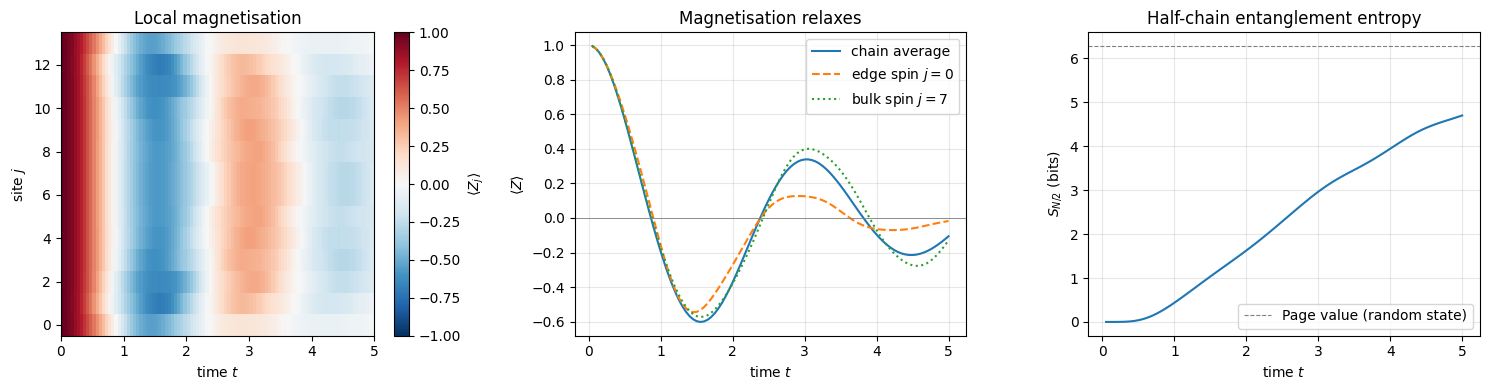

In [16]:
# ==============================================================================
# STEP 7: a trajectory = outer scan over time steps, inner scan over Chebyshev terms
# ==============================================================================
def z_profile(psi):
    """Local magnetisations <Z_j>, j = 0..N-1, from the probabilities |psi|^2.
    MATH   <Z_j> = p_j(0) - p_j(1),   p_j(s) = sum over all other axes of |psi|^2."""
    p = jnp.abs(psi) ** 2
    N = psi.ndim
    marg = jnp.stack([jnp.sum(p, axis=tuple(q for q in range(N) if q != j)) for j in range(N)])    # (N, 2)
    return marg[:, 0] - marg[:, 1]


def chebyshev_trajectory(psi0, terms, bounds, dt, n_steps, observe, tol=1e-13):
    """Evolve for n_steps*dt, recording observe(psi) after every step.  Returns (psi_final, observables, K).
    JAX   the returned trajectory is ONE jitted program: scan(time) of scan(Chebyshev terms)."""
    step, K = make_chebyshev_step(terms, bounds, dt, tol)

    def body(psi, _):
        psi = step(psi)
        return psi, observe(psi)

    run = jax.jit(lambda psi: lax.scan(body, psi, None, length=n_steps))
    psi_final, obs = run(psi0)
    return psi_final, obs, K


# ==============================================================================
# PARAMETERS of the quench
# ==============================================================================
N_q = N_big                 # chain length (= 14: we reuse the Hamiltonian terms and spectral bounds of the previous cell)
terms_q, bounds_q = terms_big, bounds_big
T_MAX = 5.0                 # final time (units of 1/J)
N_SHOTS = 100               # number of recorded times  ->  dt = T_MAX / N_SHOTS
dt_q = T_MAX / N_SHOTS


def observe_quench(psi):
    return dict(z=z_profile(psi),
                S=entanglement_entropy(psi, range(N_q // 2)),
                norm=jnp.linalg.norm(psi),
                energy=energy(terms_q, psi))


t0 = time.perf_counter()
psi_T, obs, K_q = chebyshev_trajectory(zero_state(N_q), terms_q, bounds_q, dt_q, N_SHOTS, observe_quench)
jax.block_until_ready(psi_T)
t_traj = time.perf_counter() - t0
times_q = dt_q * np.arange(1, N_SHOTS + 1)
print(f"N = {N_q}: {N_SHOTS} steps of dt = {dt_q} with K = {K_q} terms each  ->  {N_SHOTS * K_q} applications of H;  "
      f"wall time incl. compilation {t_traj:.1f} s")
print(f"max |norm - 1| along the trajectory = {float(jnp.max(jnp.abs(obs['norm'] - 1))):.1e}")
print(f"max |E(t) - E(0)|                   = {float(jnp.max(jnp.abs(obs['energy'] - E0))):.1e}")
assert float(jnp.max(jnp.abs(obs['norm'] - 1))) < 100 * TOL

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im = axes[0].imshow(np.asarray(obs["z"]).T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1,
                    extent=[0, T_MAX, -0.5, N_q - 0.5])
plt.colorbar(im, ax=axes[0], label=r"$\langle Z_j\rangle$")
axes[0].set_xlabel("time $t$"); axes[0].set_ylabel("site $j$"); axes[0].set_title("Local magnetisation")
axes[1].plot(times_q, np.asarray(obs["z"]).mean(axis=1), label="chain average")
axes[1].plot(times_q, np.asarray(obs["z"])[:, 0], "--", label="edge spin $j=0$")
axes[1].plot(times_q, np.asarray(obs["z"])[:, N_q // 2], ":", label=f"bulk spin $j={N_q // 2}$")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].set_xlabel("time $t$"); axes[1].set_ylabel(r"$\langle Z\rangle$"); axes[1].set_title("Magnetisation relaxes"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(times_q, obs["S"])
axes[2].axhline(N_q // 2 - 1 / (2 * np.log(2)), color="gray", ls="--", lw=0.8, label="Page value (random state)")
axes[2].set_xlabel("time $t$"); axes[2].set_ylabel("$S_{N/2}$ (bits)"); axes[2].set_title("Half-chain entanglement entropy"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.**

* *Magnetisation.* The transverse field rotates the spins away from $+z$ and the exchange couplings spread the disturbance: $\langle Z_j\rangle$ drops from 1, overshoots, and performs
  damped oscillations around a small value. The edge spins (one neighbour instead of two) follow visibly different curves from the bulk spins, and the reflection symmetry of the open chain
  $j\leftrightarrow N-1-j$ is evident in the colour map — a free sanity check of the code.
* *Entanglement.* The half-chain entropy grows roughly linearly — the hallmark of a quench in a generic interacting chain — and begins to bend over near $t\approx5$.
  Its stationary value is expected below that of a random state (dashed, Page), because the initial energy $E(0)=6.5$ differs from the infinite-temperature value $\mathrm{Tr}\,H/2^N=0$ and the chain is finite. The initial product state needed $2N$ numbers; by $t\approx5$ its
  half-chain entropy has reached about three quarters of the Page value, i.e. the state is already close to as complex as a state of this chain can be. This is why long-time dynamics of generic chains is restricted to small $N$ and is the natural habitat of exact state-vector methods like this one.
* *Diagnostics.* Over the whole trajectory the norm is conserved to $2\times10^{-13}$ and the energy to $4\times10^{-12}$, i.e. $5\times10^{-13}$ relative to $E(0)$.

> **Physics insight.** The model is non-integrable: apart from energy and two discrete symmetries (the reflection $j\leftrightarrow N-1-j$ and the spin-flip parity $\prod_jX_j$) it has no conservation laws, so local observables relax to stationary values that depend on the initial
> state essentially only through its energy density. The relaxation of $\langle Z\rangle$ above is a small-scale view of this; the physics is explored in depth in
> [Quench dynamics in spin chains](15_quench_dynamics_spin_chains.ipynb).

### 11.2 Checkpoint: the chained trajectory against the dense solution at every time

At $N=10$ we diagonalise $H$ once and evaluate the exact state on the whole time grid as a single matrix product (`V @ (exp(-i E t) * (V† ψ0))`, vectorised over $t$).

In [17]:
# ------------------------------------------------------------------------------
# CHECKPOINT: error of the chained evolution at EVERY recorded time  (N = 10, dense reference)
# ------------------------------------------------------------------------------
amp0 = V_d.conj().T @ psi0_val.reshape(-1)                                       # <n|psi0>
psi_exact_all = (V_d @ (jnp.exp(-1j * E_d[:, None] * jnp.asarray(times_q)[None, :]) * amp0[:, None])).T   # (n_times, 2^N)

_, psi_cheb_all, _ = chebyshev_trajectory(psi0_val, terms_val, bounds_lanczos, dt_q, N_SHOTS, lambda p: p.reshape(-1))
err_t = np.asarray(jnp.linalg.norm(psi_cheb_all - psi_exact_all, axis=1))
print(f"N = {N_val}: max over {N_SHOTS} times of ||psi_cheb(t) - psi_exact(t)|| = {err_t.max():.2e}   (at the last time: {err_t[-1]:.2e})")
assert err_t.max() < 100 * TOL

N = 10: max over 100 times of ||psi_cheb(t) - psi_exact(t)|| = 5.25e-13   (at the last time: 5.25e-13)


**Interpretation.** One hundred chained steps, each of machine-precision quality, give a trajectory that is exact to $\sim10^{-13}$ at all times. The errors of the individual steps
accumulate over the chain of steps; §13.2 separates the two sources, truncation and round-off.

## 12. Cost versus TEBD at fixed accuracy

### 12.1 A common currency

Both methods spend their time in `apply_gate` einsums of cost $\mathcal O(2^N)$ each.

* One application of $H$ = one einsum per local term: $N_{\rm terms}=(N-1)+N$ einsums (bonds + fields), plus cheap additions.
* One second-order TEBD step $=2N_{\rm terms}$ gate einsums (a forward and a backward sweep of half-step gates), i.e. **the cost of two $H$-applications**;
  a fourth-order step consists of five second-order steps $\to$ ten. (Fusing neighbouring gates lowers these constants somewhat, see [TEBD](12_tebd_trotter_suzuki.ipynb); it does not change the scaling.)

So we count work in **$H$-equivalents**: Chebyshev: $K$ per step; TEBD-2: $2\times$ steps; TEBD-4: $10\times$ steps. The scaling with the target error $\varepsilon$ at fixed final time $T$:

| method | global error | work to reach error $\varepsilon$ |
|---|---|---|
| TEBD-2 | $C_2\,T\,dt^2$ | $\propto T^{3/2}\,\varepsilon^{-1/2}$ |
| TEBD-4 | $C_4\,T\,dt^4$ | $\propto T^{5/4}\,\varepsilon^{-1/4}$ |
| Chebyshev | truncation $\sim J_K(aT)$ | $aT+c(\varepsilon)\,(aT)^{1/3}$, with $c$ growing only like $\sim\log^{2/3}(1/\varepsilon)$ |

### 12.2 The measurement: a work–precision diagram

We run all three methods to $T=5$ on the $N=10$ chain for several step sizes / tolerances, measure the **true** error against the dense reference, and record
both the $H$-equivalents and the wall time of the compiled code (second call; compilation excluded and reported separately).

**Implementation notes.** For TEBD we compile *one* program per order and pass the gate matrices and the number of steps as *arguments* (so that changing $dt$ does not recompile);
the time loop is a `lax.fori_loop`, which — unlike `scan` — accepts a traced trip count. For Chebyshev we take the whole interval in a single step.

In [18]:
# ==============================================================================
# STEP 8: work-precision measurement, TEBD-2 / TEBD-4 / Chebyshev     (N = 10, T = 5, dense reference)
# ==============================================================================
def make_tebd_runner(terms, order):
    """jit-compiled  (psi, gate_matrices, n_steps) -> psi  for a fixed gate LAYOUT (which qubits, in which order).
    The matrices (which depend on dt) and n_steps are traced arguments -> one compilation serves every dt."""
    layout = [q for q, _ in tebd_gates(terms, 0.1, order)]

    @jax.jit
    def run(psi, mats, n_steps):
        def one_step(_, p):
            for q, U in zip(layout, mats):
                p = apply_gate(p, U, q)
            return p
        return lax.fori_loop(0, n_steps, one_step, psi)

    return run, len(layout)


def timed(f, *args, repeats=5):
    """(first-call time incl. compilation, best later time, result).  block_until_ready: JAX dispatch is asynchronous."""
    t0 = time.perf_counter(); out = jax.block_until_ready(f(*args)); t_first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); out = jax.block_until_ready(f(*args)); best = min(best, time.perf_counter() - t0)
    return t_first, best, out


T_wp = 5.0
psi_ref_wp = exact_state(psi0_val, T_wp)
n_terms_H = len(terms_val)
results = {"TEBD-2": [], "TEBD-4": [], "Chebyshev": []}       # entries: (parameter, H-equivalents, error, run time, first-call time)

for order, name, dts in ((2, "TEBD-2", (0.1, 0.05, 0.02, 0.01, 0.005, 0.002)), (4, "TEBD-4", (0.25, 0.1, 0.05, 0.025, 0.0125))):
    runner, n_gates = make_tebd_runner(terms_val, order)
    for dt in dts:
        n_steps = int(round(T_wp / dt))
        mats = [U for _, U in tebd_gates(terms_val, dt, order)]
        t_first, t_run, psi_out = timed(runner, psi0_val, mats, n_steps)
        err = float(jnp.linalg.norm(psi_out - psi_ref_wp))
        results[name].append((dt, n_steps * n_gates / n_terms_H, err, t_run, t_first))

for tol in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-13):
    step, K = make_chebyshev_step(terms_val, bounds_lanczos, T_wp, tol)
    t_first, t_run, psi_out = timed(step, psi0_val)
    err = float(jnp.linalg.norm(psi_out - psi_ref_wp))
    results["Chebyshev"].append((tol, K, err, t_run, t_first))

for name, rows in results.items():
    print(f"\n{name:10s}  {'dt' if 'TEBD' in name else 'tol':>8s} | H-equivalents |   error    | run time [ms] | first call incl. compile [s]")
    for par, work, err, t_run, t_first in rows:
        print(f"            {par:8.4g} | {work:13.0f} | {err:10.2e} | {1e3 * t_run:13.1f} | {t_first:6.2f}")


TEBD-2            dt | H-equivalents |   error    | run time [ms] | first call incl. compile [s]
                 0.1 |           100 |   4.53e-02 |          25.8 |   0.46
                0.05 |           200 |   1.14e-02 |          53.0 |   0.06
                0.02 |           500 |   1.82e-03 |         117.7 |   0.11
                0.01 |          1000 |   4.55e-04 |         215.6 |   0.41
               0.005 |          2000 |   1.14e-04 |         390.5 |   0.51
               0.002 |          5000 |   1.82e-05 |        1136.1 |   1.61

TEBD-4            dt | H-equivalents |   error    | run time [ms] | first call incl. compile [s]
                0.25 |           200 |   1.23e-03 |          31.0 |   1.15
                 0.1 |           500 |   3.18e-05 |          78.7 |   0.08
                0.05 |          1000 |   1.99e-06 |         170.9 |   0.20
               0.025 |          2000 |   1.25e-07 |         296.2 |   0.33
              0.0125 |          4000 |   7.80e-09 |   

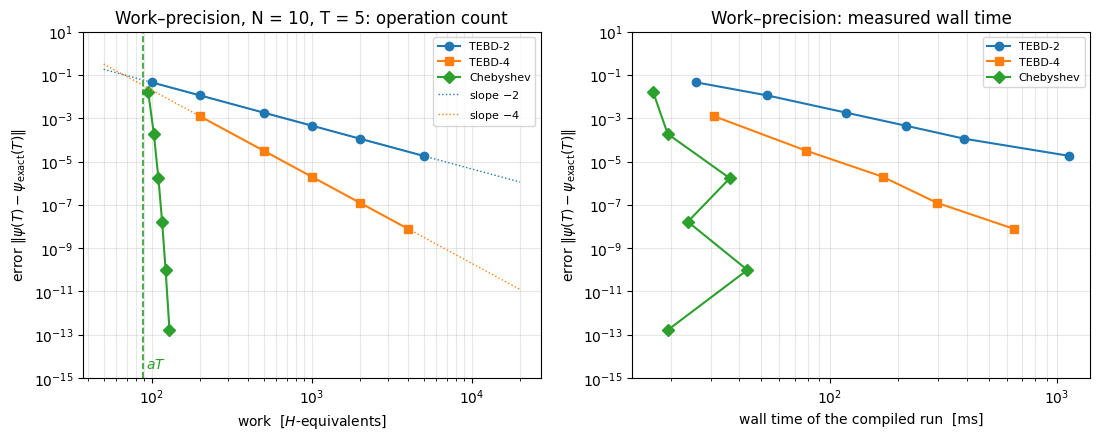

In [19]:
# ==============================================================================
# FIGURE: work-precision diagram
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
style = {"TEBD-2": ("C0", "o"), "TEBD-4": ("C1", "s"), "Chebyshev": ("C2", "D")}
for name, rows in results.items():
    work, err, t_run = (np.array([r[i] for r in rows]) for i in (1, 2, 3))
    col, mk = style[name]
    axes[0].loglog(work, err, mk + "-", color=col, label=name)
    axes[1].loglog(1e3 * t_run, err, mk + "-", color=col, label=name)
w = np.array([50.0, 2e4])
r2, r4 = results["TEBD-2"][2], results["TEBD-4"][2]
axes[0].loglog(w, r2[2] * (w / r2[1]) ** -2.0, "C0:", lw=1, label=r"slope $-2$")
axes[0].loglog(w, r4[2] * (w / r4[1]) ** -4.0, "C1:", lw=1, label=r"slope $-4$")
axes[0].axvline(1.02 * half_width(bounds_lanczos) * T_wp, color="C2", lw=1.2, ls="--"); axes[0].text(1.02 * half_width(bounds_lanczos) * T_wp * 1.05, 3e-15, "$aT$", color="C2")
axes[0].set_xlabel("work  [$H$-equivalents]"); axes[1].set_xlabel("wall time of the compiled run  [ms]")
for ax in axes:
    ax.set_ylim(1e-15, 10); ax.set_ylabel(r"error $\|\psi(T)-\psi_{\rm exact}(T)\|$"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
axes[0].set_title(f"Work–precision, N = {N_val}, T = {T_wp:g}: operation count")
axes[1].set_title("Work–precision: measured wall time")
plt.show()

**Interpretation.** Read the diagram *horizontally*: pick the accuracy you need and see what it costs.

* TEBD errors follow the power laws $\text{work}^{-2}$ and $\text{work}^{-4}$ (dotted): each extra digit costs a factor $\sqrt{10}\approx3.2$ (order 2) or $10^{1/4}\approx1.8$ (order 4) in work.
* The Chebyshev curve is nearly **vertical**: there is a minimum price of $\approx aT\approx88$ applications of $H$ (dashed line) below which the method gives nothing at all; between 95 and 129 applications
  the error falls from $10^{-2}$ to $10^{-13}$.
* Consequently there is a **crossover**, and for this task ($T=5$) it lies at a state error of a few $10^{-2}$: only for a very rough answer is TEBD-2 with a large step cheaper. At an error of $10^{-4}$ Chebyshev needs about 100 $H$-equivalents,
  TEBD-4 about 400 and TEBD-2 about 2000; at $10^{-8}$ it is about 115 against 4000 against (extrapolating the dotted line) $2\times10^5$. Machine precision is out of reach for TEBD-2 at any reasonable cost (it would take $dt\sim10^{-7}$).
* The position of the crossover depends on the task, and this diagram is one task: $N=10$, one model, $T=5$, the state-vector norm as error measure. Three dependences can be read off without re-measuring.
  *Time:* TEBD's work grows like $T^{1+1/p}$ at fixed error and Chebyshev's like $T$, so short evolutions favour TEBD and long ones Chebyshev.
  *System size:* Chebyshev work $\approx aT\propto NT$, while the Trotter error operator is extensive, $\varepsilon\sim C_pT\,dt^p$ with $C_p\propto N$, so TEBD-$p$ work $\propto T^{1+1/p}(N/\varepsilon)^{1/p}$.
  The ratio therefore scales as $N^{1-1/p}$: the Chebyshev advantage *shrinks* with $N$, but only as $\sqrt N$ against TEBD-2 and $N^{3/4}$ against TEBD-4 — going from $N=10$ to $N=30$ costs it a factor 1.7, resp. 2.3, and the measured
  advantages at $\varepsilon=10^{-4}$ (20-fold over TEBD-2, 4-fold over TEBD-4) survive comfortably.
  *Error measure:* the norm of the state error used here is the most demanding one there is; local observables are usually far more forgiving (we measure an example in §13).
* The wall-time panel tells the same story as the operation count: per $H$-equivalent the two methods cost about the same (compare the columns of the table; Chebyshev adds up terms and carries three vectors, TEBD applies unitary gates one after another),
  so the crossover does not move much.

> **Numerical practice.** Absolute timings depend on the machine and on what else is running on it (these notes were executed on a shared CPU); ratios and slopes are robust. Always compare algorithms **at equal accuracy** —
> "method A needs 0.1 s, method B 1 s" means nothing if A delivers 3 digits and B 13. And always *measure* the error against a trusted reference rather than assuming the nominal order.

Two properties favour TEBD: (i) its gates act locally, which is what makes it extendable to matrix-product states for $N\gg30$ ([MPS-TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)), and to time-dependent
Hamiltonians and noisy circuits with no extra effort; (ii) if observables are needed on a very fine time grid anyway, small steps come for free. A full comparison, including the Krylov method, follows in the
[next notebook](14_krylov_and_integrator_comparison.ipynb).

## 13. Long times: one giant step against many small ones

### 13.1 The cost of subdividing

For a final time $T$ split into $n$ steps of $\Delta t = T/n$ the total work is, by Eq. (10),

$$ W(n)=n\,K\!\big(a\,\Delta t\big)\approx aT+n^{2/3}\,c\,(aT)^{1/3} : $$

the unavoidable $aT$ plus an overhead that grows with the number of steps. **Fewer, larger steps are cheaper**, the opposite of finite-difference time stepping. There is no stability
limit and no accuracy penalty for a large step. The reasons to subdivide are practical: you want observables at intermediate times; the Hamiltonian changes in time (piecewise constant $H$);
or $K$ becomes so large that rounding errors in the recurrence, which grow linearly with $K$, start to matter.

The middle reason deserves a warning. A Hamiltonian that is *genuinely* piecewise constant (a field switched at known instants, as in Exercise 8) costs nothing:
build one propagator per constant piece and every step is still exact. A *smoothly* time-dependent $H(t)$ is a different matter — freezing it at the midpoint of
each step, $U(\Delta t)\approx e^{-iH(t_n+\Delta t/2)\Delta t}$, commits a local error $\mathcal{O}(\Delta t^3)$ and a global one $\mathcal{O}(\Delta t^2)$. The time-step
error is back, $\Delta t$ must again be chosen by accuracy rather than by convenience, and the main selling point of this notebook is gone. Chebyshev propagation
is a method for time-independent Hamiltonians.

We measure both aspects: the work $W$ as a function of $\Delta t$ (pure arithmetic with `chebyshev_coefficients`), and the actual error at a *long* time, $T=100$ — that is $aT\approx1800$ —
for different subdivisions, against the dense solution. For comparison we also run TEBD-2 with $dt=0.01$ over the same interval.

In [20]:
# ==============================================================================
# EXPERIMENT: long-time evolution T = 100 at N = 10 with different step sizes
# ==============================================================================
T_long = 100.0
a_long = 1.02 * half_width(bounds_lanczos)
amp_T = jnp.exp(-1j * E_d * T_long) * amp0
psi_exact_long = (V_d @ amp_T).reshape((2,) * N_val)

print(f"a T = {a_long * T_long:.0f}")
print("   dt    | steps | K per step | total H applications | overhead vs aT |   error at T=100   | norm - 1")
for dt_long in (100.0, 10.0, 1.0, 0.1):
    n_long = int(round(T_long / dt_long))
    psi_long, _, K_long = chebyshev_trajectory(psi0_val, terms_val, bounds_lanczos, dt_long, n_long, lambda p: 0.0)
    err_long = float(jnp.linalg.norm(psi_long - psi_exact_long))
    print(f" {dt_long:7.1f} | {n_long:5d} | {K_long:10d} | {n_long * K_long:20d} | {n_long * K_long / (a_long * T_long):13.2f}x | {err_long:18.2e} | {float(jnp.linalg.norm(psi_long)) - 1:+.1e}")
    assert err_long < 1e4 * TOL

runner2, n_gates2 = make_tebd_runner(terms_val, 2)
print()
for dt_tebd in (0.05, 0.01):
    n_tebd = int(round(T_long / dt_tebd))
    psi_tebd = runner2(psi0_val, [U for _, U in tebd_gates(terms_val, dt_tebd, 2)], n_tebd)
    err_z = float(jnp.max(jnp.abs(z_profile(psi_tebd) - z_profile(psi_exact_long))))
    print(f"TEBD-2, dt = {dt_tebd:4.2f}: {n_tebd:5d} steps = {2 * n_tebd:5d} H-equivalents;  state error at T=100 = {float(jnp.linalg.norm(psi_tebd - psi_exact_long)):.2e};"
          f"  max_j |<Z_j> - exact| = {err_z:.1e};  norm - 1 = {float(jnp.linalg.norm(psi_tebd)) - 1:+.1e}")

a T = 1760
   dt    | steps | K per step | total H applications | overhead vs aT |   error at T=100   | norm - 1


   100.0 |     1 |       1869 |                 1869 |          1.06x |           3.94e-13 | -6.2e-14


    10.0 |    10 |        228 |                 2280 |          1.30x |           1.27e-12 | +2.4e-13


     1.0 |   100 |         43 |                 4300 |          2.44x |           3.53e-12 | +4.8e-13


     0.1 |  1000 |         15 |                15000 |          8.52x |           8.39e-12 | -4.5e-13



TEBD-2, dt = 0.05:  2000 steps =  4000 H-equivalents;  state error at T=100 = 2.52e-01;  max_j |<Z_j> - exact| = 1.4e-02;  norm - 1 = -3.3e-12


TEBD-2, dt = 0.01: 10000 steps = 20000 H-equivalents;  state error at T=100 = 1.01e-02;  max_j |<Z_j> - exact| = 4.7e-04;  norm - 1 = -5.2e-11


**Interpretation.**

* A **single step of length $T=100$** — a polynomial of degree $\approx1900$ in $H$ — gives the state to $4\times10^{-13}$ with only 6 % more work than the unavoidable $aT$: the recurrence is stable, errors grow only gently with the degree.
* Subdividing increases the work: by 30 % for $\Delta t=10$, by a factor 2.4 for $\Delta t=1$, and by a factor 8.5 for $\Delta t=0.1$, where the constant overhead ($\sim10$–$15$ terms per step) dominates $a\Delta t\approx1.8$.
  The accuracy stays at the $10^{-12}$ level in all cases, degrading slowly (from $4\times10^{-13}$ to $8\times10^{-12}$) as the number of chained steps grows from 1 to 1000 — the error of the individual steps accumulates (§13.2).
* TEBD-2 is left far behind. With $dt=0.05$ (4 000 $H$-equivalents — as much as the $\Delta t=1$ Chebyshev run) the state error at $T=100$ is $0.25$, a quarter of the way to the
  maximum $\sqrt2$ that two orthogonal unit vectors can have; with $dt=0.01$ it spends 20 000 $H$-equivalents — five times the Chebyshev budget — to reach $10^{-2}$, still ten orders of magnitude worse.
  The error grows linearly in time, $\propto T\,dt^2$, so long times are exactly where it hurts. Its norm, however, is perfect to $10^{-11}$: **a unitary propagator can still be far from the exact one**.
* Local observables are much more forgiving than the state vector, as always: at $dt=0.01$ the worst magnetisation $\langle Z_j\rangle$ is off by only $5\times10^{-4}$, at $dt=0.05$ by $1.4\times10^{-2}$.

> **Numerical practice.** Rule of thumb for Chebyshev propagation: choose $\Delta t$ as the spacing at which you want to *see* observables, provided $a\Delta t\gtrsim10$; below that you are paying mostly overhead.
> Local observables (magnetisations) are often fine with a much larger TEBD error than the full state vector — the state error is the most demanding measure — but for echoes, overlaps and long times there is no substitute for an exact propagator.

### 13.2 Accumulation of truncation and round-off errors

Without a Trotter error, a single Chebyshev step still carries two errors:

1. **Truncation.** We stopped the series at $K$, so a deterministic $\delta_{\rm trunc}\lesssim2\sum_{k>K}|J_k(a\Delta t)|\sim\text{`tol`}$ is left over.
   It is the *same* operator at every step, so over $n$ chained steps it adds up **coherently**: $n\,\delta_{\rm trunc}$.
2. **Round-off.** Each of the $K$ recurrence steps commits rounding errors of relative size $\varepsilon=2.2\times10^{-16}$; because both solutions of the
   recurrence are bounded on $[-1,1]$ (§3.2), they are not amplified, and one step accumulates at most $\sim K\varepsilon$. Part of this error is the same at every
   step (the rounded coefficients $c_k$, the rounded $a$, $b$ and phase define a slightly different but *fixed* polynomial) and adds up coherently; the rest changes
   from step to step and partly cancels.

Only the first one is under our control, through `tol`. In the table above the two are mixed (both $K$ and $n$ change from row to
row), so we separate them: fix $\Delta t=0.5$, vary only $n$, and repeat with a tighter `tol`.

In [21]:
# ==============================================================================
# EXPERIMENT: coherent (truncation) versus incoherent (round-off) accumulation
#             fixed dt = 0.5, n = 1, 10, 100 chained steps, two tolerances      (N = 10)
# ==============================================================================
dt_acc = 0.5
print(f"  dt = {dt_acc} (z = a dt = {a_long * dt_acc:.1f})")
print("     tol   |  K | err(n=1)  | err(n=10) | err(n=100) | growth exponent p  (err ~ n^p)")
for tol_acc in (1e-13, 1e-15):
    errs_acc = []
    for n_acc in (1, 10, 100):
        psi_acc, _, K_acc = chebyshev_trajectory(psi0_val, terms_val, bounds_lanczos, dt_acc, n_acc, lambda p: 0.0, tol=tol_acc)
        errs_acc.append(float(jnp.linalg.norm(psi_acc - exact_state(psi0_val, dt_acc * n_acc))))
    p_acc = np.log(errs_acc[2] / errs_acc[0]) / np.log(100.0)
    print(f"   {tol_acc:7.0e} | {K_acc:2d} | {errs_acc[0]:9.2e} | {errs_acc[1]:9.2e} | {errs_acc[2]:10.2e} | {p_acc:6.2f}")
print(f"  for reference: K * machine epsilon = {K_acc * np.finfo(float).eps:.2e} per step")

  dt = 0.5 (z = a dt = 8.8)
     tol   |  K | err(n=1)  | err(n=10) | err(n=100) | growth exponent p  (err ~ n^p)


     1e-13 | 29 |  5.25e-14 |  5.25e-13 |   5.24e-12 |   1.00


     1e-15 | 31 |  2.81e-15 |  1.91e-14 |   1.70e-13 |   0.89
  for reference: K * machine epsilon = 6.88e-15 per step


**Interpretation.** With the default `tol`$=10^{-13}$ the per-step error is $\sim5\times10^{-14}$ and it grows with an exponent $p\approx1$: **linear, coherent
accumulation of the truncation error**, exactly as predicted. Tightening `tol` to $10^{-15}$ costs two extra terms out of $\sim30$ and drops the single-step error
by a factor of 20, to the round-off floor (compare it with the printed $K\varepsilon$). What is left still grows with $p\approx0.9$, far from the $p=1/2$ of a random walk:
round-off, too, accumulates almost linearly, because part of it is the same fixed perturbation in every step. The gain lies in the prefactor, which drops from
$\sim$`tol` to $\sim\varepsilon$ per step: after 100 steps the error is $\sim2\times10^{-13}$ instead of $5\times10^{-12}$. The slow degradation in the long-time table is therefore
mostly truncation, and it is cheap to remove.

> **Numerical practice.** Two rules follow.
> **(i)** Chaining $n$ steps at tolerance `tol` gives a final error of about $n\cdot$`tol`, so choose `tol` $\approx\varepsilon_{\rm target}/n$ — it costs only
> $\propto(\ln 1/\text{tol})^{2/3}$ extra terms by Eq. (10a), which is nearly free.
> **(ii)** Below that lies a hard floor: a single step cannot be more accurate than the round-off of its own recurrence, of order $K\varepsilon$ — compare the
> printed reference value with the `tol`$=10^{-15}$ row above, and note that the one-shot $T=100$ run ($K=1869$, so $K\varepsilon=4\times10^{-13}$) came out at
> $4\times10^{-13}$. No choice of `tol` reaches below this floor.

## 14. Performance and the reach in system size

Memory: four state vectors (three in the carry plus one temporary) of $16\times2^N$ bytes each in double precision — 64 MB at $N=20$, 16 GB at $N=28$. Time: $K\approx1.02\,aT+\dots$ applications
of $H$, each $\mathcal{O}(N2^N)$, with $a\approx1.8N$ for our model, so the total cost of reaching a fixed time $T$ scales as $\mathcal O(N^2\,2^N\,T)$. Let us measure one Chebyshev step of length $t=1$ for
growing $N$, separating compilation from execution. We use a cheap rigorous-ish estimate for the bounds here — a short Lanczos run with $m=20$ — to keep the set-up time small.

  N |    2^N    |   a    |  K  | compile+first run [s] | run [s] | run / (K N 2^N) [ns] | norm - 1


  8 |       256 |  14.30 |  38 |                  0.29 |   0.002 |                20.04 | +6.4e-15


 10 |      1024 |  18.01 |  43 |                  0.51 |   0.007 |                16.45 | +1.1e-14


 12 |      4096 |  21.91 |  49 |                  0.47 |   0.034 |                14.08 | -5.3e-15


 14 |     16384 |  25.67 |  54 |                  0.78 |   0.170 |                13.76 | -7.7e-15


 16 |     65536 |  29.30 |  59 |                  1.73 |   0.858 |                13.87 | -6.6e-15


 18 |    262144 |  33.03 |  63 |                  5.26 |   4.639 |                15.60 | +0.0e+00


 20 |   1048576 |  36.68 |  68 |                 19.06 |  18.363 |                12.88 | -2.0e-15


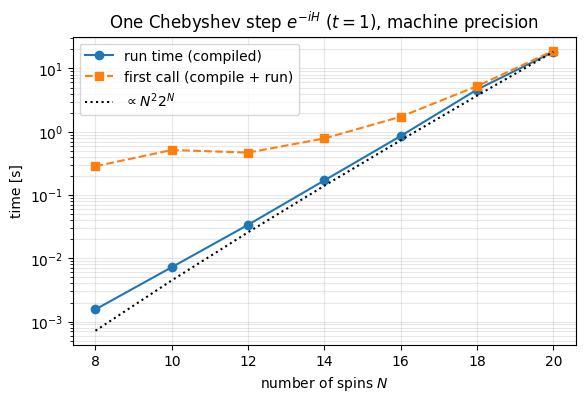

In [22]:
# ==============================================================================
# BENCHMARK: one Chebyshev step exp(-iH t), t = 1, versus N   (compile time and run time separated)
# ==============================================================================
t_bench = 1.0
print("  N |    2^N    |   a    |  K  | compile+first run [s] | run [s] | run / (K N 2^N) [ns] | norm - 1")
bench = []
for N_b in (8, 10, 12, 14, 16, 18, 20):
    terms_b = model_terms(N_b)
    bounds_b = spectral_bounds(terms_b, N_b, m=20)
    step_b, K_b = make_chebyshev_step(terms_b, bounds_b, t_bench, safety=1.05)      # m=20 Lanczos is cruder -> larger safety margin
    t_first, t_run, psi_b = timed(step_b, zero_state(N_b), repeats=3 if N_b <= 14 else 1)
    bench.append((N_b, K_b, t_first, t_run))
    print(f" {N_b:2d} | {2 ** N_b:9d} | {1.05 * half_width(bounds_b):6.2f} | {K_b:3d} | {t_first:21.2f} | {t_run:7.3f} | {1e9 * t_run / (K_b * N_b * 2 ** N_b):20.2f} | {float(jnp.linalg.norm(psi_b)) - 1:+.1e}")
    assert abs(float(jnp.linalg.norm(psi_b)) - 1) < 1e3 * TOL

fig, ax = plt.subplots(figsize=(6.5, 4))
Ns_b = np.array([r[0] for r in bench]); run_b = np.array([r[3] for r in bench]); first_b = np.array([r[2] for r in bench])
ax.semilogy(Ns_b, run_b, "o-", label="run time (compiled)")
ax.semilogy(Ns_b, first_b, "s--", label="first call (compile + run)")
ax.semilogy(Ns_b, run_b[-1] * (Ns_b / Ns_b[-1]) ** 2 * 2.0 ** (Ns_b - Ns_b[-1]), "k:", label=r"$\propto N^2 2^N$")
ax.set_xlabel("number of spins $N$"); ax.set_ylabel("time [s]"); ax.set_title(r"One Chebyshev step $e^{-iH}$ ($t=1$), machine precision")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

**Interpretation.** For small $N$ the run time is dominated by fixed overheads (dispatch, tiny arrays) and the compile time dwarfs it; from $N\approx12$ on the curve follows the predicted $N^22^N$ law — a factor of four to five for every two additional spins — and the
time per elementary operation (last-but-one column) stops growing and, apart from timing noise, drifts slowly *downwards*, because larger arrays use the cache and the vector units better. Read that column for its trend only: its absolute value depends on the machine and on what else is running on it
(these notes are executed on a shared CPU, and the same cell can differ by a factor of several between runs). The norm column confirms that the cruder $m=20$ bounds with a 5 % safety margin were sufficient at every size (had they not been, the norm would have exploded, §8).
A million-dimensional state ($N=20$) is propagated by $e^{-iH}$ to machine precision in well under a minute on a CPU; on a GPU the same code runs unchanged (set `DEVICE` in the configuration cell) and the large-$N$ end of the curve drops by a large factor.

> **JAX practice.** Compile time is *per shape*: a new $N$, a new number of coefficients $K$ — new compilation. In parameter scans keep $\Delta t$ (hence $K$) fixed and vary what enters as *values*. If you must vary $\Delta t$, you can pad the coefficient array with zeros to a common length at the cost of some wasted applications of $H$.

## 15. Summary — key takeaways

* With only $H|\phi\rangle$ available, $e^{-iHt}|\psi\rangle$ must be approximated by a polynomial in $H$; by the spectral theorem this is a *scalar* approximation problem for $e^{-ixt}$ on the interval containing the spectrum.
* **Taylor is the wrong polynomial** (catastrophic cancellation). **Chebyshev is the right one**: $T_k(\cos\theta)=\cos k\theta$, bounded by 1 on $[-1,1]$, generated by the three-term recurrence $T_{k+1}=2xT_k-T_{k-1}$; Chebyshev series are Fourier cosine series in $\theta$.
* The coefficients of $e^{-izx}$ are Bessel functions, $c_k=(2-\delta_{k0})(-i)^kJ_k(z)$ (Jacobi–Anger). $J_k(z)$ is $\mathcal O(z^{-1/2})$ for $k<z$ and decays super-exponentially for $k>z$: the number of terms is $K\approx z+c\,z^{1/3}$ with $z=at$, and the first omitted coefficient is a reliable a-priori error estimate.
* The Hamiltonian must be rescaled so that its spectrum lies in $[-1,1]$: $\tilde H=(H-b)/a$. Bounds from a short Lanczos run lie *inside* the spectrum $\Rightarrow$ safety factor. Over-estimating $a$ costs proportionally more work; under-estimating it makes the result explode. Watch the norm.
* Implementation: coefficients once in SciPy; recurrence as a `lax.scan` with carry $(\phi_{k-1},\phi_k,\Sigma)$; trajectories as a scan of scans. Memory: four state vectors. Cost: $\approx at$ applications of $H$, i.e. $\mathcal O(N^22^Nt)$ for a chain.
* There is no time-step error, but there are exactly two other errors and both are quantified: the **truncation** at `tol`, which accumulates *linearly* over $n$ chained steps (so take `tol` $\approx\varepsilon_{\rm target}/n$),
  and the **round-off** of the recurrence, of order $\varepsilon$ to $K\varepsilon$ per step, which also accumulates almost linearly (partly coherently) and is a hard floor. Wrong spectral bounds are a third, catastrophic failure mode rather than an error.
* The truncated propagator is not exactly unitary, so the norm is a free monitor — but by Eq. (9a) it under-reports the error by the overlap with the offending eigenvectors and must be read as a lower bound.
* Compared with TEBD at equal accuracy, Chebyshev loses for rough answers and wins by orders of magnitude for precise ones and for long times; the advantage shrinks only as $N^{1-1/p}$ with system size.
* Large steps are *more* efficient than small ones; the step is chosen by the desired sampling of observables.
* Limitations: time-independent (or piecewise constant) $H$ with a **real** spectrum of known extent; the full state vector must fit in memory; no direct extension to matrix-product states with truncation.

## 16. Exercises

1. ★ **Chebyshev by hand.** Use recurrence (3) to derive $T_5(x)$ and verify with `chebyshev_T` on a grid. Show from definition (2) that $T_k(1)=1$, $T_k(-1)=(-1)^k$ and that the zeros of $T_k$ are $x_j=\cos\big(\pi(j+\tfrac12)/k\big)$; check numerically.
2. ★ **Bessel sum rules.** Verify numerically $\sum_{k=-\infty}^{\infty}J_k(z)=1$ (set $\theta=\pi/2$ in the textbook form of the Jacobi–Anger identity) and $J_0^2+2\sum_{k\ge1}J_k^2=1$ for several $z$, using `jv`. Which physical property of the propagator does the second one express?
3. ★ **Backward evolution.** `make_chebyshev_step(..., dt=-t)` evolves backward in time. Explain, using $J_k(-z)=(-1)^kJ_k(z)$, why the backward coefficients are the complex conjugates of the forward ones, and verify it with `chebyshev_coefficients`.
4. ★★ **Single precision.** Set `PRECISION = "single"` in the configuration cell and rerun §10. Where is the rounding floor now? What `tol` is sensible? How does the floor grow with the number of chained steps in §13?
5. ★★ **Imaginary time (extend the code).** Nothing in `chebyshev_apply` is specific to $e^{-izx}$ (§7.4). Implement $e^{-\tau H}$: compute the coefficients of $f(x)=e^{-\tau a x}$ both with the midpoint rule of §4 and from the closed form $c_k=(2-\delta_{k0})(-1)^kI_k(\tau a)$ (`scipy.special.iv`), and check that they agree. Apply the step to a Haar-random state and normalise. Use several moderate steps (e.g. twenty steps of $\tau=1$) rather than one huge one: $I_k(\tau a)$ grows like $e^{\tau a}$ and overflows for $\tau a\gtrsim700$, for which `scipy.special.ive` is the cure. At $N=10$ and total $\tau=20$ the energy should match `lanczos_ground_state` from [Hamiltonians and ground states](11_hamiltonians_and_ground_states.ipynb) to $\sim10^{-13}$. Two questions: how does the number of terms needed at relative accuracy `tol` grow with $\tau a$ (use $I_k(w)/I_0(w)\approx e^{-k^2/2w}$ for $1\ll k\ll w$; you should find $K\approx\sqrt{2\tau a\ln(1/\text{tol})}$, far fewer than the $K\approx at$ of real time when $\tau a$ is large), and why is there no cancellation catastrophe of §2.2 even though every term is of size $e^{\tau a}$?
6. ★★ **Loschmidt echo (physics).** Compute $\mathcal L(t)=|\langle\psi(0)|\psi(t)\rangle|^2$ for the quench of §11 up to $t=10$ at $N=14$ with Chebyshev, and with TEBD-2 at $dt=0.05$ and $0.01$. Plot on a logarithmic scale. At which value of $\mathcal L$ does each TEBD curve become unreliable, and why is this observable so much more sensitive than $\langle Z_j\rangle$?
7. ★★ **Wrong bounds, quantitatively.** For the experiment of §8 predict the norm of the corrupted state from the *first omitted* term of the series, $2\,\vert J_{K+1}(z)\vert\,T_{K+1}(1/s)$ with $T_{K+1}(1/s)=\cosh\big((K+1)\,\mathrm{arccosh}(1/s)\big)$ and $z=s\,a\,t$, times the overlap of $|\psi_0\rangle$ with the extremal eigenvectors (dense, $N=10$). The truncation order is the engine's: $K=\lceil z\rceil+20$, raised in steps of 10 until $|J_K(z)|<$ `tol`. Compare with the measured norms — at $s=0.9$ and $0.8$ this single term should account for them to about 20 %. At $s=0.98$ the same estimate comes out far below 1, so it predicts not the norm but the *error* column; check that as well.
8. ★★★ **Piecewise-constant driving (extend the code).** Let the field switch periodically between $h_x=1$ and $h_x=0$ every $\tau=0.5$ (a Floquet drive). Build the two Chebyshev steps once and alternate them inside a `lax.scan` (hint: `lax.cond` on the step parity, or scan over pairs of steps). Record the energy with respect to the *average* Hamiltonian and the half-chain entropy: does the energy drift towards $0$, the energy of the maximally mixed state, and does the entropy approach the Page value?

## 17. References

* H. Tal-Ezer and R. Kosloff, *An accurate and efficient scheme for propagating the time dependent Schrödinger equation*, J. Chem. Phys. **81**, 3967 (1984) — the original Chebyshev propagator.
* C. Leforestier *et al.*, *A comparison of different propagation schemes for the time dependent Schrödinger equation*, J. Comput. Phys. **94**, 59 (1991).
* A. Weiße, G. Wellein, A. Alvermann and H. Fehske, *The kernel polynomial method*, Rev. Mod. Phys. **78**, 275 (2006) — Chebyshev expansions for densities of states, spectral functions and dynamical correlation functions, with damping kernels (Jackson kernel).
* H. Fehske, J. Schleede, G. Schubert, G. Wellein, V. S. Filinov and A. R. Bishop, *Numerical approaches to time evolution of complex quantum systems*, Phys. Lett. A **373**, 2182 (2009).
* C. Moler and C. Van Loan, *Nineteen dubious ways to compute the exponential of a matrix, twenty-five years later*, SIAM Review **45**, 3 (2003).
* M. Abramowitz and I. A. Stegun (eds.), *Handbook of Mathematical Functions with Formulas, Graphs, and Mathematical Tables*, Dover, New York (1965;
  reprint of National Bureau of Standards Applied Mathematics Series **55**, 1964) — chapter 9 (Bessel functions of integer order: 9.1.21 integral
  representations, 9.1.62 upper bound, 9.3 asymptotics for large order) and chapter 22 (orthogonal polynomials). Its modern successor is the NIST Digital
  Library of Mathematical Functions, https://dlmf.nist.gov (10.9.2 and 10.14.4 are the same two formulas).
* L. N. Trefethen, *Approximation Theory and Approximation Practice*, Other Titles in Applied Mathematics **128**, SIAM (2013) — why Chebyshev expansions are
  near-optimal polynomial approximations (Ch. 16, "Best and Near-Best").
* J. C. Mason and D. C. Handscomb, *Chebyshev Polynomials*, Chapman & Hall/CRC, Boca Raton (2003), ISBN 978-0-8493-0355-5.
* L. N. Trefethen and J. A. C. Weideman, *The exponentially convergent trapezoidal rule*, SIAM Review **56**, 385–458 (2014).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed., Cambridge University Press
  (2007) — §5.8 Chebyshev approximation, §6.5 Bessel functions of integer order; and *Numerical Recipes in Fortran 90: The Art of Parallel Scientific
  Computing*, 2nd ed., Cambridge University Press (1996).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/